In [1]:
from libra_toolbox.neutron_detection.diamond.process_data import DataProcessor
from matplotlib import pyplot as plt
import numpy as np
import os
from pathlib import Path
import process_diamond

In [2]:


measurements = process_diamond.get_measurements_from_json(channel=0)




Processing measurement at path: ../../data/diamond/260225_Starfire_nGen_characterization/DAQ/-9deg/RAW
['DataR_CH2@DT5730SB_14779_-9deg.BIN', 'DataR_CH4@DT5730SB_14779_-9deg.BIN', 'DataR_CH0@DT5730SB_14779_-9deg.BIN', 'DataR_CH6@DT5730SB_14779_-9deg.BIN', 'DataR_CH5@DT5730SB_14779_-9deg.BIN', 'DataR_CH3@DT5730SB_14779_-9deg.BIN', 'DataR_CH7@DT5730SB_14779_-9deg.BIN']
Found data file: DataR_CH2@DT5730SB_14779_-9deg.BIN
Found data file: DataR_CH4@DT5730SB_14779_-9deg.BIN
Found data file: DataR_CH0@DT5730SB_14779_-9deg.BIN
Found data file: DataR_CH6@DT5730SB_14779_-9deg.BIN
Found data file: DataR_CH5@DT5730SB_14779_-9deg.BIN
Found data file: DataR_CH3@DT5730SB_14779_-9deg.BIN
Found data file: DataR_CH7@DT5730SB_14779_-9deg.BIN
Found data files:  {2: array(['DataR_CH2@DT5730SB_14779_-9deg.BIN'], dtype='<U34'), 4: array(['DataR_CH4@DT5730SB_14779_-9deg.BIN'], dtype='<U34'), 0: array(['DataR_CH0@DT5730SB_14779_-9deg.BIN'], dtype='<U34'), 6: array(['DataR_CH6@DT5730SB_14779_-9deg.BIN'], dtype

In [3]:
def gaussian(x, mu, sigma, A, B):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + B


 -9deg
Bases:  [np.int64(1371), np.int64(1833)]
Optimal parameters:  [1600.95628438   25.69569085  187.11029611   12.35998034]
Difference between mean and index:  1.0437156245031929
N alpha mean:  1600.9562843754968  std:  25.695690851847544

 -18deg


/tmp/ipykernel_24577/827794730.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  float(np.diff(n_alpha_bases[name])), float(np.max(hist)), float(np.max(hist))])


Bases:  [np.int64(1461), np.int64(1729)]
Optimal parameters:  [1597.39776372   25.1511146   192.30039138   12.58403127]
Difference between mean and index:  -2.397763717649468
N alpha mean:  1597.3977637176495  std:  25.151114599139635

 -27deg
Bases:  [np.int64(1497), np.int64(1701)]
Optimal parameters:  [1591.79192096   23.53392972  209.25832874   13.4804978 ]
Difference between mean and index:  7.208079039159429
N alpha mean:  1591.7919209608406  std:  23.533929720909402

 -36deg
Bases:  [np.int64(1473), np.int64(1711)]
Optimal parameters:  [1583.64572494   21.65169274  216.65019442   12.98235669]
Difference between mean and index:  8.354275064706599
N alpha mean:  1583.6457249352934  std:  21.65169274208425

 -45deg
Bases:  [np.int64(1356), np.int64(1792)]
Optimal parameters:  [1573.87096302   19.80349838  258.93717659   13.94577117]
Difference between mean and index:  0.12903698290278953
N alpha mean:  1573.8709630170972  std:  19.803498381280363

 -54deg
Bases:  [np.int64(1464), n

/tmp/ipykernel_24577/827794730.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, a = plt.subplots(figsize=[6, 3])


Bases:  [np.int64(1436), np.int64(1694)]
Optimal parameters:  [1562.26165306   17.13635589  290.73061577   16.69697389]
Difference between mean and index:  2.7383469356268506
N alpha mean:  1562.2616530643731  std:  17.13635588668662

 63deg
Bases:  [np.int64(1319), np.int64(1775)]
Optimal parameters:  [1547.7284461    14.74307151  349.0671326    16.75895731]
Difference between mean and index:  -0.7284460983423742
N alpha mean:  1547.7284460983424  std:  14.743071509678057

 72deg
Bases:  [np.int64(1357), np.int64(1711)]
Optimal parameters:  [1532.94075854   11.58081457  363.93643253   16.2919861 ]
Difference between mean and index:  1.0592414594023012
N alpha mean:  1532.9407585405977  std:  11.58081457433428

 81deg
Bases:  [np.int64(1310), np.int64(1726)]
Optimal parameters:  [1517.70661584    9.49863952  434.33861538   17.37641675]
Difference between mean and index:  0.2933841557021424
N alpha mean:  1517.7066158442979  std:  9.498639524727823

 90deg
Bases:  [np.int64(1403), np.in

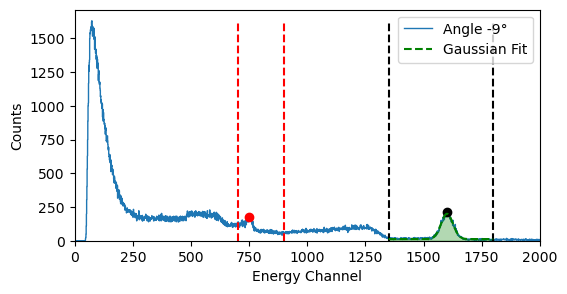

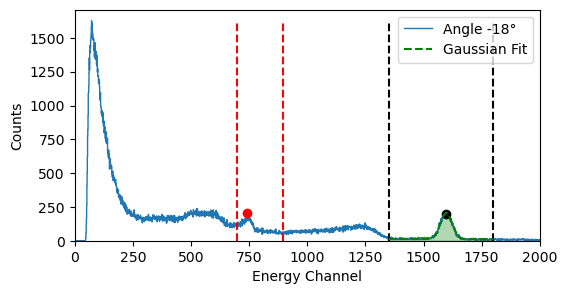

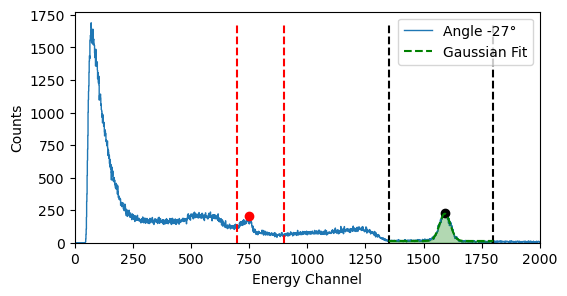

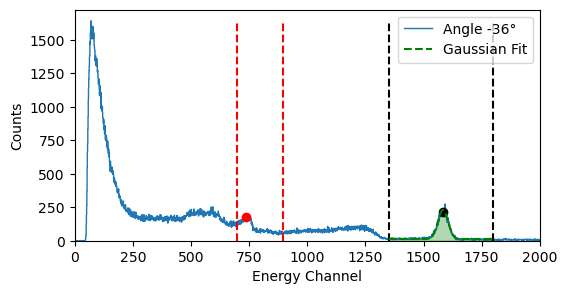

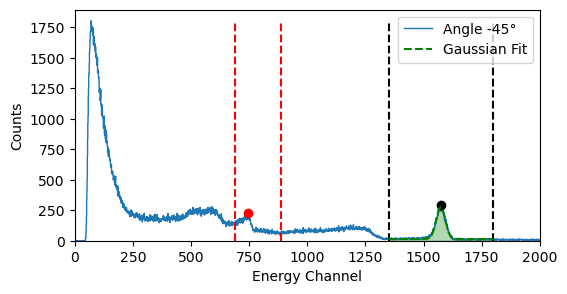

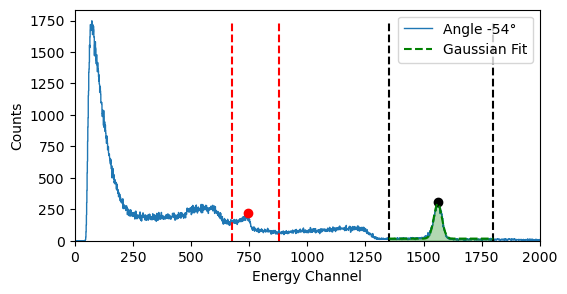

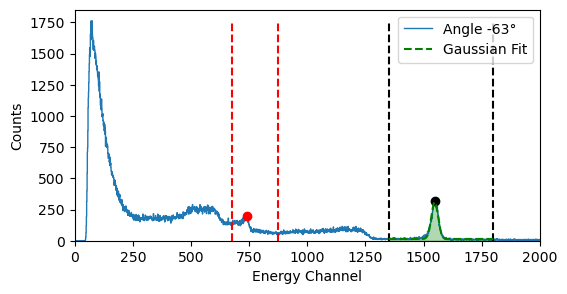

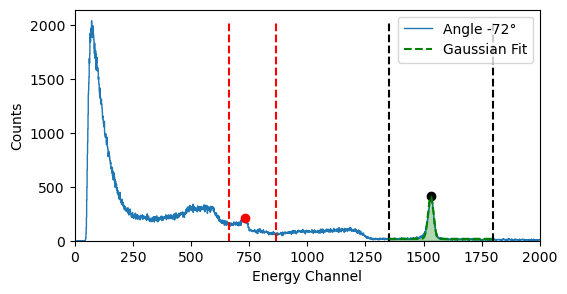

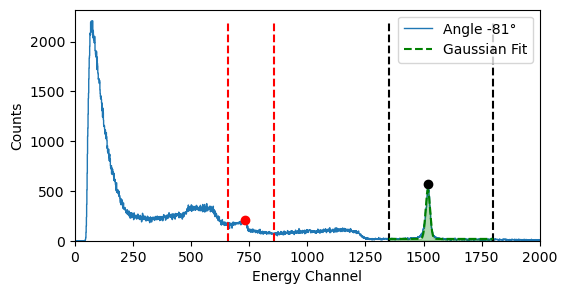

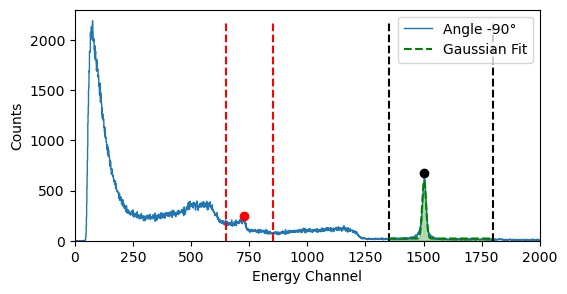

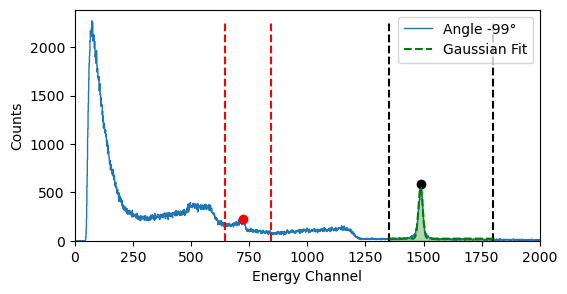

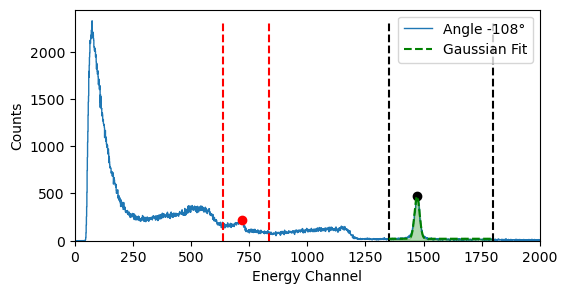

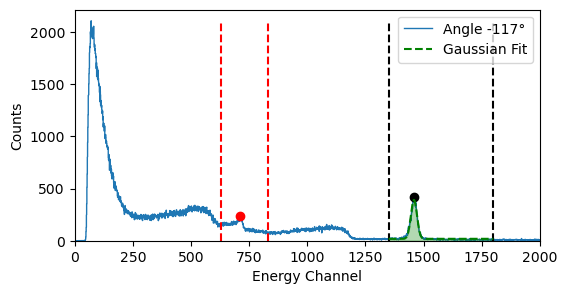

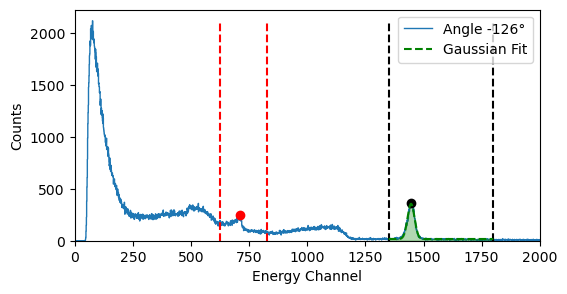

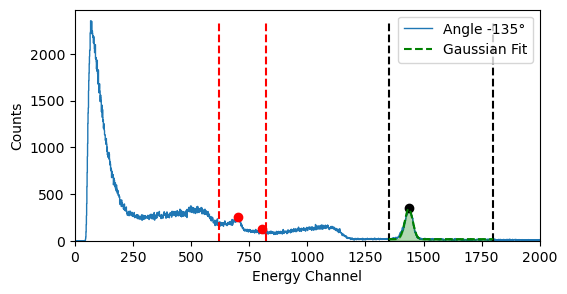

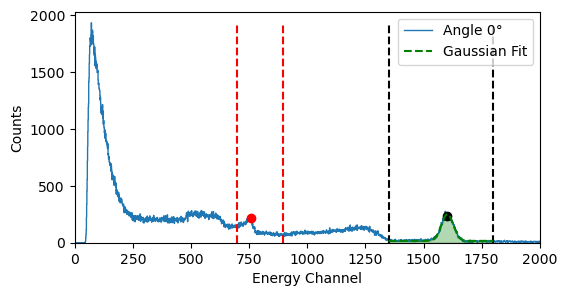

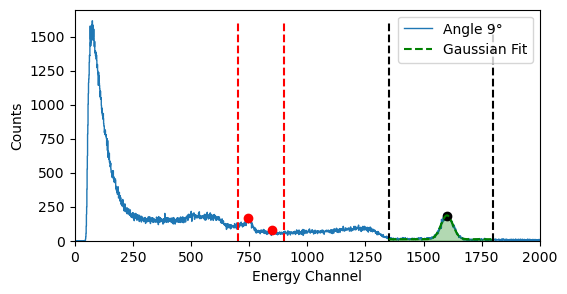

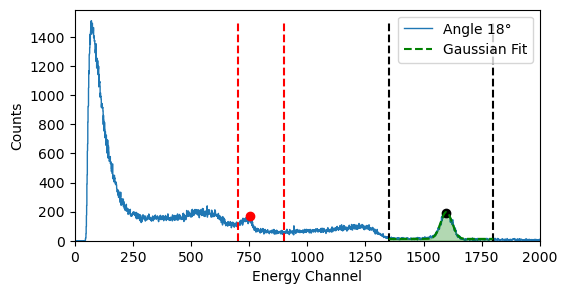

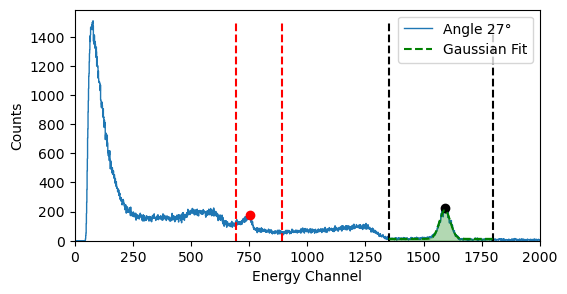

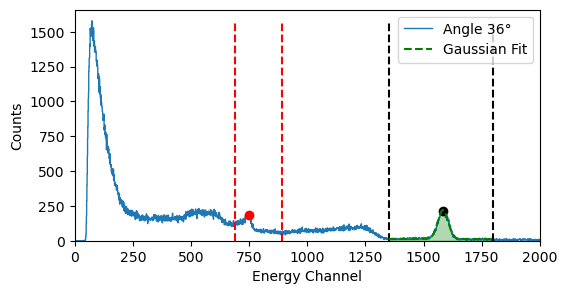

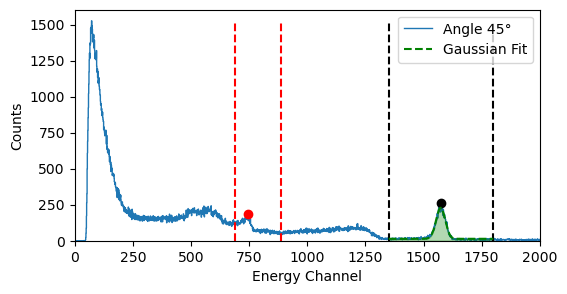

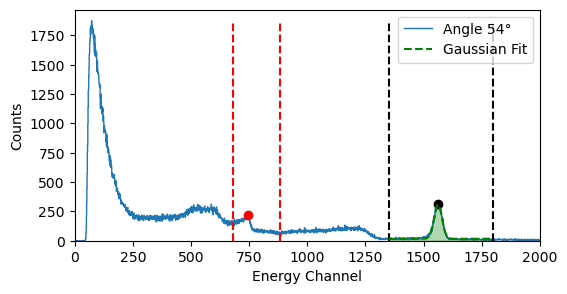

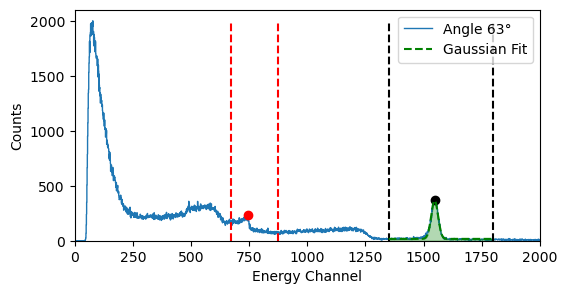

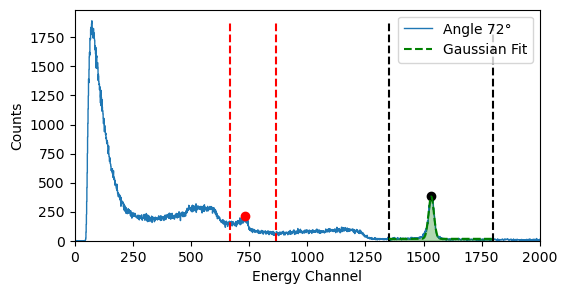

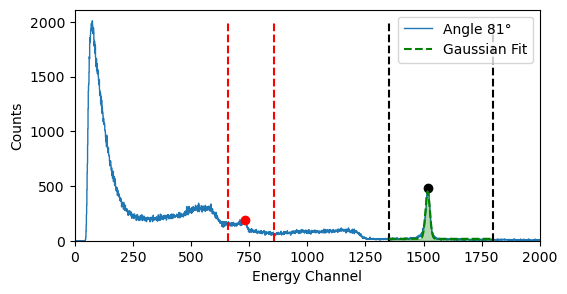

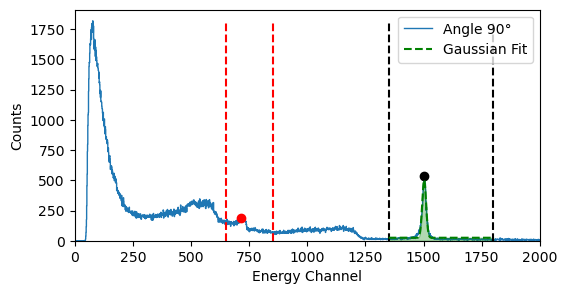

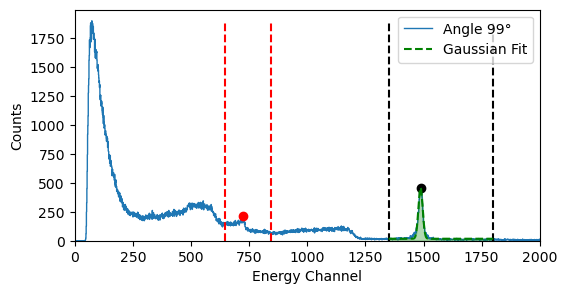

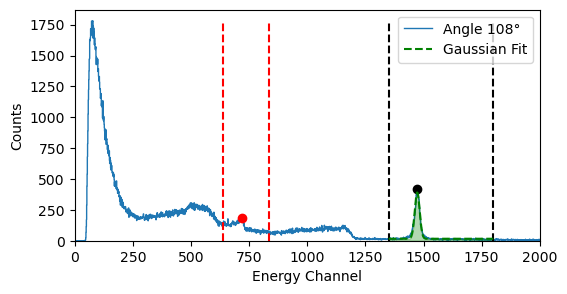

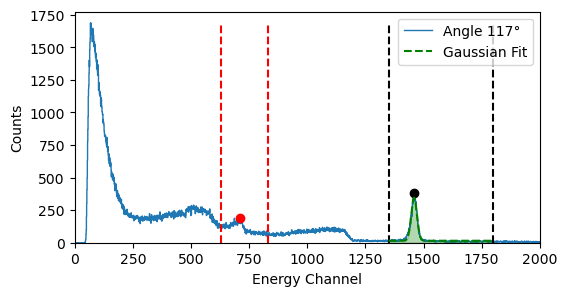

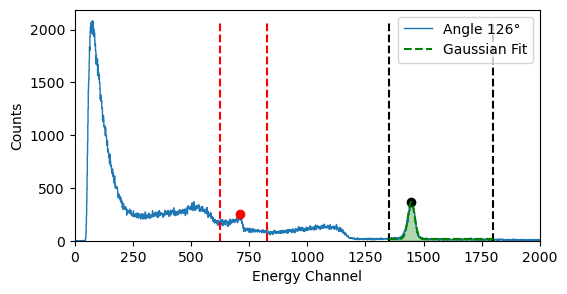

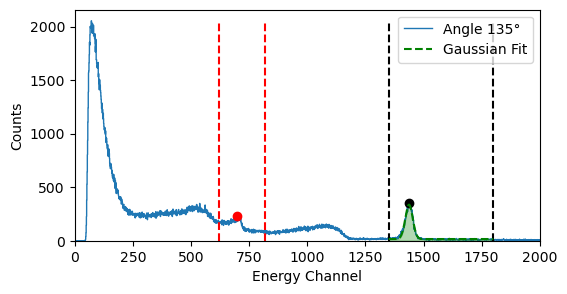

In [4]:
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

n_alpha_inds = {}
elastic_inds = {}
n_alpha_bases = {}
n_alpha_bases_inds = {}
n_alpha_means = {}
n_alpha_stds = {}
peak_areas = {}
nrows = int(np.sqrt(len(measurements)))
ncols = int(np.ceil(len(measurements) / nrows))
# fig, ax = plt.subplots(figsize=[20,20], nrows=nrows, ncols=ncols)
for name in measurements:
    print('\n', name)
    fig, a = plt.subplots(figsize=[6, 3])
    data_processor = measurements[name]
    angle = data_processor.angle
    bins = np.arange(0, 4000, 1)
    hist, bins = np.histogram(data_processor.energy_values, bins=bins)
    a.stairs(hist, bins, label=f'Angle {angle}°')
    peaks, peak_data = find_peaks(hist, height=np.max(hist)*0.1, 
                                  distance=20, 
                                  prominence=np.max(hist)*0.1)
    half_width = peaks[1] - peak_data['left_bases'][1]
    n_alpha_bases_inds[name] = [peak_data['left_bases'][1], int(peaks[1] + half_width)]
    n_alpha_bases[name] = [bins[n_alpha_bases_inds[name][0]], bins[n_alpha_bases_inds[name][1]]]
    n_alpha_ind = peaks[1]
    # a.vlines(n_alpha_bases[name], 0, np.max(hist), colors='k', linestyles='dashed')
    print("Bases: ", n_alpha_bases[name])

    left_ind = np.searchsorted(bins, 1350)
    right_ind = np.searchsorted(bins, 1800)
    a.vlines(bins[right_ind], 0, np.max(hist), colors='k', linestyles='dashed')
    a.vlines(bins[left_ind], 0, np.max(hist), colors='k', linestyles='dashed')

    guess = [float(bins[n_alpha_ind]), 5, hist[n_alpha_ind], 0]
    bounds = ([float(n_alpha_bases[name][0]), 0, 0, 0],
                      [float(n_alpha_bases[name][1]), 
                       float(np.diff(n_alpha_bases[name])), float(np.max(hist)), float(np.max(hist))])
    # print('Guess: ', guess)
    # print('Bounds: ', bounds)
    popt, popc = curve_fit(gaussian, 
              bins[n_alpha_bases_inds[name][0]:n_alpha_bases_inds[name][1]], 
              hist[n_alpha_bases_inds[name][0]:n_alpha_bases_inds[name][1]], 
              p0=guess,
              bounds=bounds
             )
    
    print('Optimal parameters: ', popt)
    # store values
    n_alpha_means[name] = popt[0]
    n_alpha_stds[name] = popt[1]

    # plot mean
    mean_index = np.searchsorted(bins, n_alpha_means[name])
    a.plot(n_alpha_means[name], hist[mean_index], "o", color="black")
    # plot fit
    # fit_x = np.linspace(n_alpha_means[name] - 6 * n_alpha_stds[name], 
    #                     n_alpha_means[name] + 6 * n_alpha_stds[name],
    #                     200)
    fit_x = np.linspace(bins[left_ind], bins[right_ind], 400)
    fit_y = gaussian(fit_x, *popt)
    peak_areas[name] = np.trapezoid(fit_y, fit_x)
    average_bins = (bins[left_ind:right_ind] + bins[left_ind+1:right_ind+1]) / 2 

    # peak_areas[name] = np.trapezoid(hist[left_ind:right_ind], average_bins)
    # background_area = np.trapezoid(popt[3]*np.ones_like(fit_x), fit_x)
    # print('Peak area: ', peak_areas[name], ' Background area: ', background_area)
    # background_y = popt[3]*np.ones_like(fit_x)
    # peak_areas[name] -= background_area

    a.plot(fit_x, fit_y, 'g--', label='Gaussian Fit')
    a.fill_between(fit_x, fit_y, alpha=0.3, color='g')
    print('Difference between mean and index: ', n_alpha_ind - n_alpha_means[name])
    print('N alpha mean: ', n_alpha_means[name], ' std: ', n_alpha_stds[name])

    # find elastic peak index
    start_index = int(n_alpha_ind*0.5 - 100)
    end_index = int(n_alpha_ind*0.5 + 100)
    hist_segment = hist[start_index:end_index]
    peaks2, peak_data2 = find_peaks(hist_segment, height=np.max(hist_segment)*0.2, 
                                    distance=100, 
                                    prominence=np.max(hist_segment)*0.2)
    a.plot(bins[start_index + peaks2], hist[start_index + peaks2], "or")
    a.vlines(bins[start_index], 0, np.max(hist), colors='r', linestyles='dashed')
    a.vlines(bins[end_index], 0, np.max(hist), colors='r', linestyles='dashed')
    elastic_ind = start_index + peaks2[0]

    a.set_xlabel('Energy Channel')
    a.set_ylabel('Counts')
    a.legend()
    a.set_xlim(0, 2000)

    n_alpha_inds[name] = n_alpha_ind
    elastic_inds[name] = elastic_ind

Processing measurement at path: ../../data/diamond/260225_Starfire_nGen_characterization/DAQ/Ra226_calib/RAW
['DataR_CH7@DT5730SB_14779_Ra226_calib.BIN', 'DataR_CH6@DT5730SB_14779_Ra226_calib.BIN', 'DataR_CH2@DT5730SB_14779_Ra226_calib.BIN', 'DataR_CH4@DT5730SB_14779_Ra226_calib.BIN:Zone.Identifier', 'DataR_CH4@DT5730SB_14779_Ra226_calib.BIN', 'DataR_CH3@DT5730SB_14779_Ra226_calib.BIN', 'DataR_CH0@DT5730SB_14779_Ra226_calib.BIN', 'DataR_CH5@DT5730SB_14779_Ra226_calib.BIN', 'DataR_CH7@DT5730SB_14779_Ra226_calib.BIN:Zone.Identifier', 'DataR_CH5@DT5730SB_14779_Ra226_calib.BIN:Zone.Identifier', 'DataR_CH2@DT5730SB_14779_Ra226_calib.BIN:Zone.Identifier', 'DataR_CH6@DT5730SB_14779_Ra226_calib.BIN:Zone.Identifier', 'DataR_CH3@DT5730SB_14779_Ra226_calib.BIN:Zone.Identifier', 'DataR_CH0@DT5730SB_14779_Ra226_calib.BIN:Zone.Identifier']
Found data file: DataR_CH7@DT5730SB_14779_Ra226_calib.BIN
Found data file: DataR_CH6@DT5730SB_14779_Ra226_calib.BIN
Found data file: DataR_CH2@DT5730SB_14779_Ra22

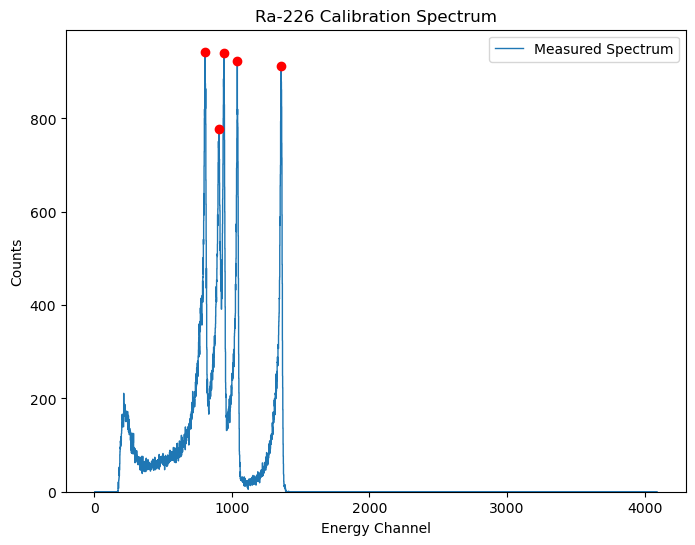

In [5]:
calibration_measurements = process_diamond.get_calibration_measurements_from_json(channel=0)
hist, bins = np.histogram(calibration_measurements['Ra226'].energy_values, 
                          bins=calibration_measurements['Ra226'].channel_bins)
fig, ax = plt.subplots(figsize=[8,6])
ax.stairs(hist, bins, label='Measured Spectrum')
ax.set_xlabel('Energy Channel')
ax.set_ylabel('Counts')
ax.legend()
ax.set_title('Ra-226 Calibration Spectrum')
calibration_channels, calibration_energies = process_diamond.calibrate_diamond(calibration_measurements)
peak_indices = [np.where(bins == ch)[0][0] for ch in calibration_channels]
ax.plot(calibration_channels, hist[peak_indices], 'ro', label='Calibration Peaks')

In [6]:
print(calibration_energies)
calibration_coeffs = np.polyfit(calibration_channels, calibration_energies, 1)
print('Calibration coefficients: ', calibration_coeffs)

[4424.1, 4965.9, 5158.0, 5688.7, 7418.0]
Calibration coefficients:  [ 5.42142711 48.79291122]


lower ind:  1338  upper ind:  1706  calibrated bins at lower ind:  7302.662377980619  calibrated bins at upper ind:  9297.747552695639


Text(0.5, 1.0, 'Diamond Spectra by Angle')

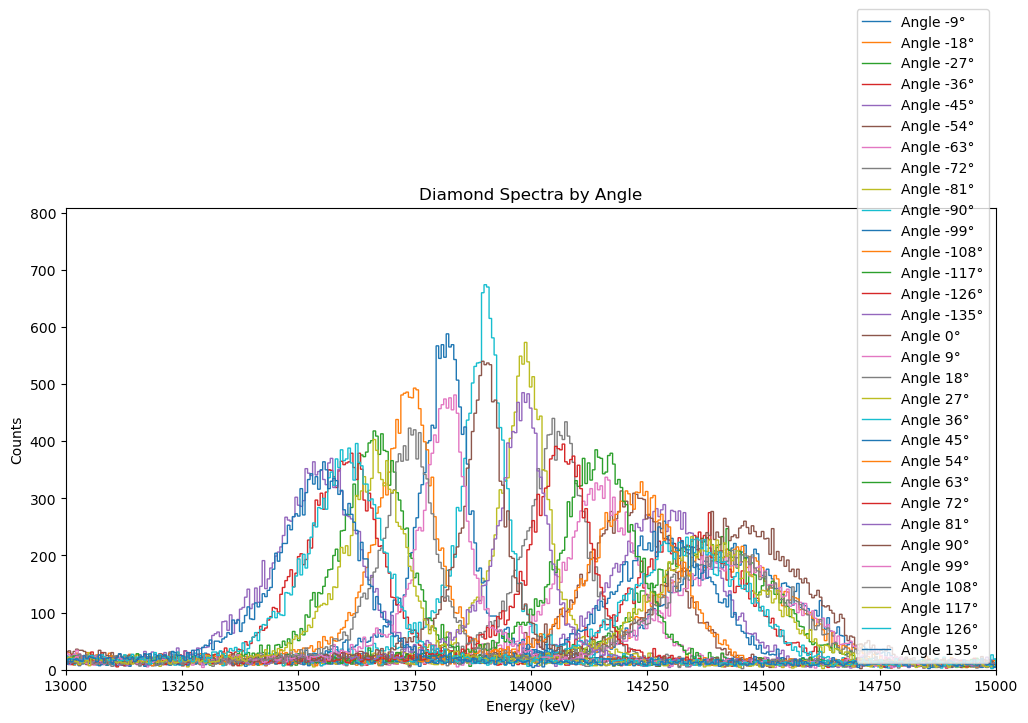

In [7]:
# c12_na_threshold = 6181.84 #keV
c12_na_threshold = 5702 #keV

fig, ax = plt.subplots(figsize=[12,6])
for name, measurement in measurements.items():
    hist, bins = np.histogram(measurement.energy_values, bins=measurement.channel_bins)
    calibrated_bins = np.polyval(calibration_coeffs, bins)
    if measurement.angle == -90:
        lower_ind = np.where(calibrated_bins + c12_na_threshold >= 13000)[0][0]
        upper_ind = np.where(calibrated_bins + c12_na_threshold <= 15000)[0][-1]
        print("lower ind: ", lower_ind, " upper ind: ", upper_ind,
              " calibrated bins at lower ind: ", calibrated_bins[lower_ind], 
              " calibrated bins at upper ind: ", calibrated_bins[upper_ind])
        max_height = np.max(hist[lower_ind:upper_ind])
    ax.stairs(hist, calibrated_bins + c12_na_threshold, label=f'Angle {measurement.angle}°')

ax.set_xlim(13000, 15000)
ax.set_ylim(0, max_height*1.2)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel('Counts')
ax.legend()
ax.set_title('Diamond Spectra by Angle')


In [8]:
import sys
sys.path.append('../')
from process_nGen_data import get_time_slice

[       36814217      1132396873      1769517311 ... 183297549885686
 183300282614873 183301014906342]
[      882541187      2151663249      3071381811 ... 156226559179279
 156226634830030 156228242523998]
[      155770436       288530123      2228556185 ... 159764442308001
 159764790804186 159765548445873]
[      223164562       329774185       810357873 ... 155137294501218
 155138078138001 155138292091342]
[     1615544000      1814593999      1854750123 ... 164305317347748
 164305450813123 164305726466124]
[      293315654       384007624      1086547248 ... 162524040582936
 162524797355748 162524961770937]
[      829996468      1126482436      1127567498 ... 163232504406874
 163233028829404 163233563476030]
[      865122842      1069279186      1503884155 ... 191301558558623
 191301889309810 191302184833968]
[     1633371999      1671692029      1752275999 ... 210187364011874
 210187952977812 210188225561936]
[      488079436      2347481811      2959302216 ... 196077576608217
 196

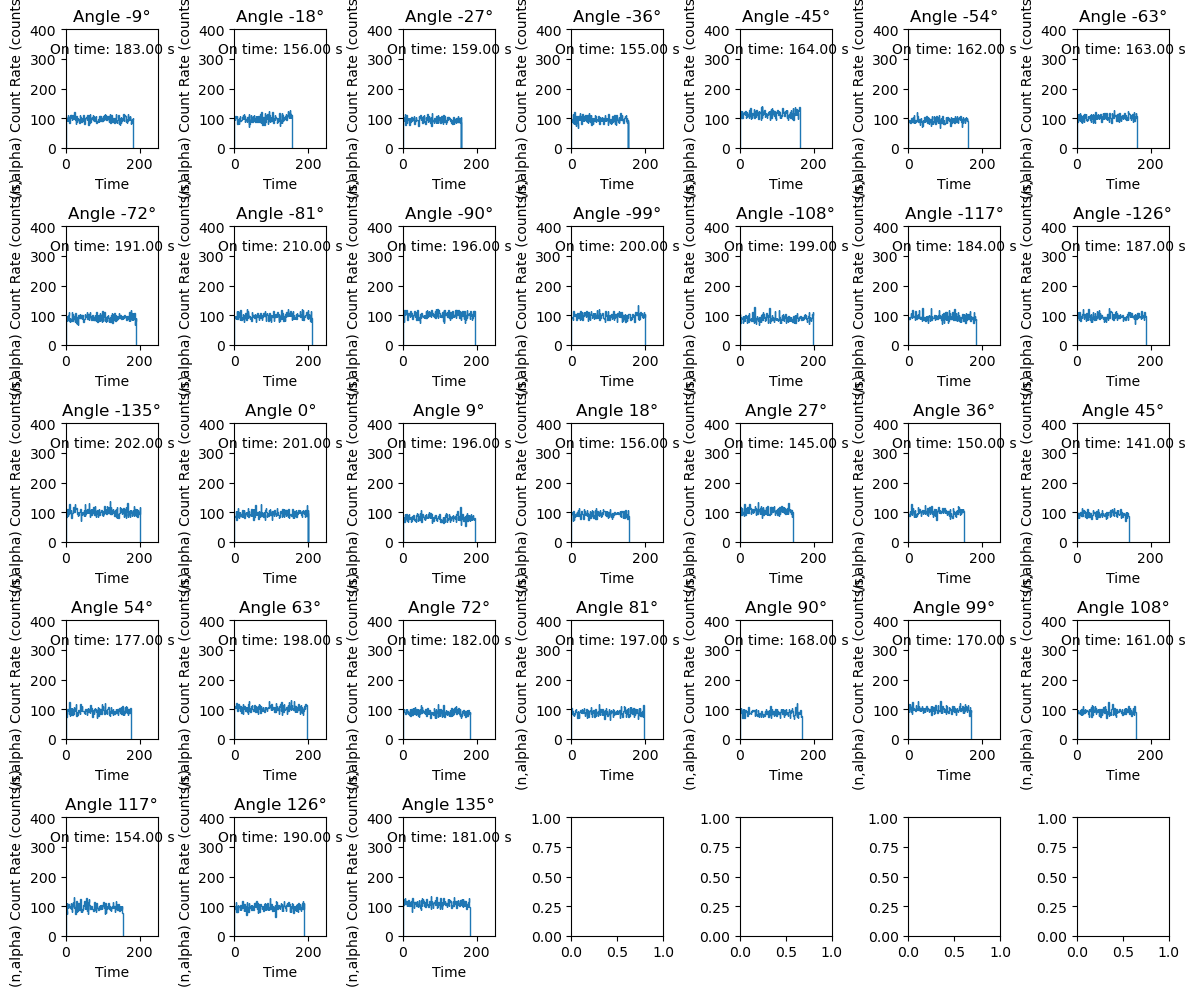

In [9]:
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=[12,10])
on_times = {}
for a,name in zip(ax.flatten(), measurements):
    data_processor = measurements[name]
    print(data_processor.time_values)
    count_rate, count_rate_bins = data_processor.get_count_rate(bin_time=1e12, 
                                                                energy_window=n_alpha_bases[name])
    count_rate_bins /= 1e12  # convert to seconds
    count_rate *= 1e12  # convert to counts/s

    on_mask = count_rate > 50
    count_rate_intervals = np.diff(count_rate_bins)
    on_times[name] = sum(count_rate_intervals[on_mask])
    a.stairs(count_rate, count_rate_bins)
    a.set_xlabel('Time')
    a.set_ylabel('(n,alpha) Count Rate (counts/s)')
    a.set_title(f'Angle {measurements[name].angle}°')
    a.text(0.5, 0.8, f'On time: {on_times[name]:.2f} s', transform=a.transAxes, ha='center')
    a.set_ylim(0, 400)
    a.set_xlim(0, 250)
    # find time at max count rate
    max_ind = np.argmax(count_rate)
    max_rate_time = count_rate_bins[max_ind]

    # # plot twin axis with generator power
    # twin_ax = a.twinx()
    # elapsed_times, voltages, currents, powers = get_time_slice(
    #     data_processor.start_time,
    #     data_processor.stop_time
    # )
    # # find time at max power
    # max_power_ind = np.argmax(powers)
    # max_power_time = np.array(elapsed_times)[max_power_ind]
    # time_diff = max_power_time - max_rate_time
    # elapsed_times = np.array(elapsed_times) - time_diff
    # twin_ax.plot(elapsed_times, powers, 'r-', alpha=0.5)
    # twin_ax.set_ylabel('Generator Power (W)', color='r')
    # twin_ax.tick_params(axis='y', labelcolor='r')
    # twin_ax.set_ylim(0, 0.06)

    # total_energy_output = np.trapezoid(powers, elapsed_times)
    # a.text(0.5, 0.7, f'Electric Energy: {total_energy_output:.2f} kJ', transform=a.transAxes, ha='center', color='red')



fig.tight_layout()

In [10]:
for key in on_times:
    # convert time to seconds
    time_diff = (measurements[key].stop_time - measurements[key].start_time).total_seconds()
    if np.abs(time_diff - on_times[key]) > 1:  # if total time and on time differ by more than 1 second, print warning
        print(f"Warning: Total time and on time differ for {key}. Total time: {time_diff:.2f} s, On time: {on_times[key]:.2f} s")


on_times as measured by filtering the n,alpha signal count rate agrees with the total measurement count time up to a 1 second error.

Elastic max energy deposition at 90 degrees:  4.004733727810651
Calibration coefficients: [ 0.00566864 -0.12203645]


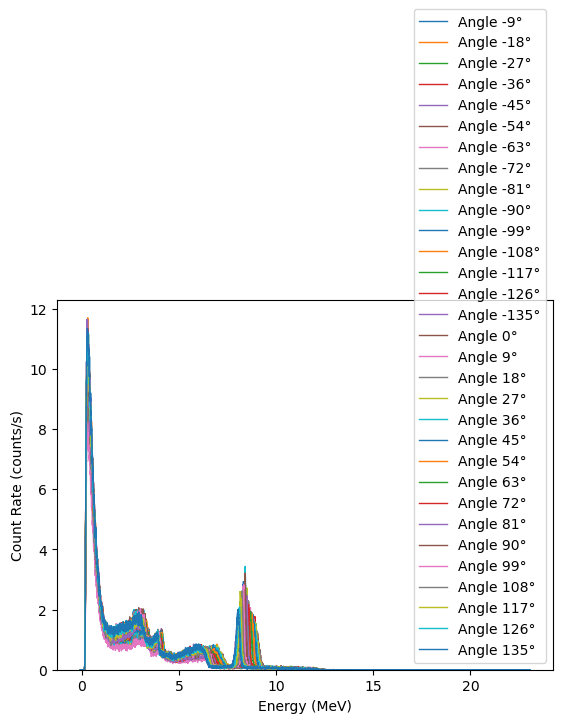

In [11]:
n_alpha_q_value = -5.70207
n_alpha_threshold = 6.18184
energy_90deg = 14.10
alpha = ((12 - 1)/(12 + 1))**2  # for carbon
elastic_max_energy_dep = energy_90deg * (1 - alpha)
n_alpha_peak_energy = energy_90deg + n_alpha_q_value

def elastic_max_energy_deposition(neutron_initial_energy, alpha=((12 - 1)/(12 + 1))**2):
    return neutron_initial_energy * (1 - alpha)

elastic_max_energy_dep_90 = elastic_max_energy_deposition(energy_90deg)
print('Elastic max energy deposition at 90 degrees: ', elastic_max_energy_dep_90)

coeff = np.polyfit([elastic_inds['-90deg'], n_alpha_inds['-90deg']],
                   [elastic_max_energy_dep_90, n_alpha_peak_energy], 1)
print(f'Calibration coefficients: {coeff}')
fig, ax = plt.subplots()
for name in measurements:
    data_processor = measurements[name]
    angle = measurements[name].angle
    bins = data_processor.channel_bins
    hist, bins = np.histogram(data_processor.energy_values, bins=bins) 
    a_energy = coeff[0] * bins + coeff[1]
    data_processor.spectrum = hist
    data_processor.channel_bins = bins
    data_processor.energy_bins = a_energy
    n_alpha_means[name] = coeff[0] * n_alpha_means[name] + coeff[1]
    n_alpha_stds[name] = coeff[0] * n_alpha_stds[name]
    ax.stairs(np.array(hist) / on_times[name], a_energy, label=f'Angle {angle}°')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Count Rate (counts/s)')
ax.legend()



Calibration looks good! The expected elastic edges match what the calibration calculated. Yayyy!!

/tmp/ipykernel_24577/2732164503.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, a = plt.subplots(figsize=[7,4])


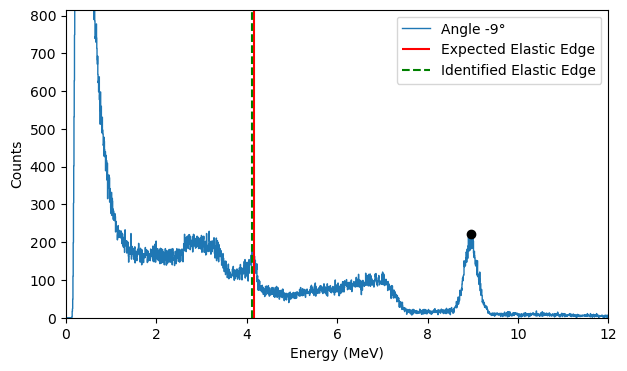

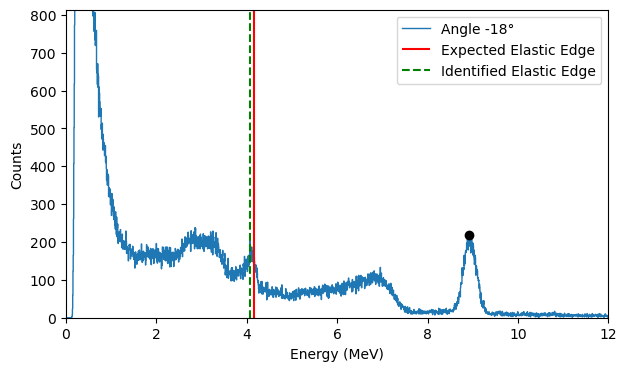

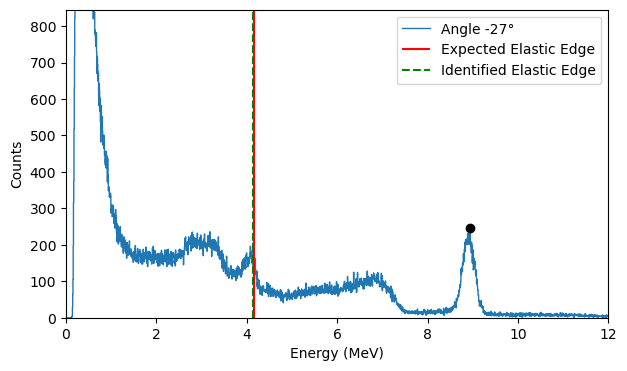

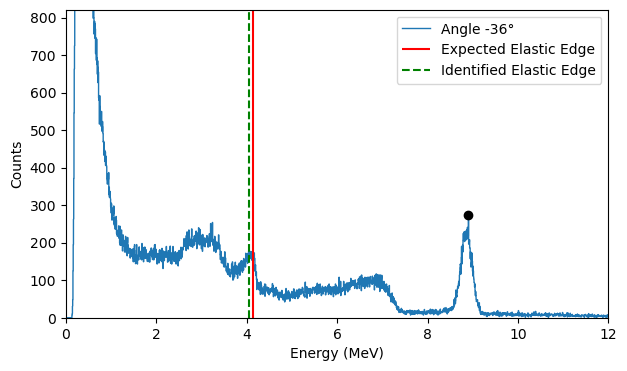

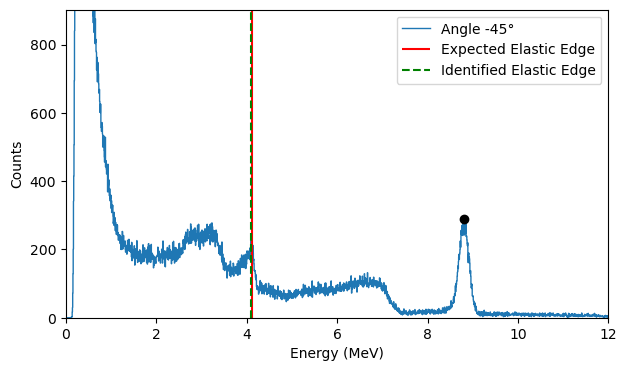

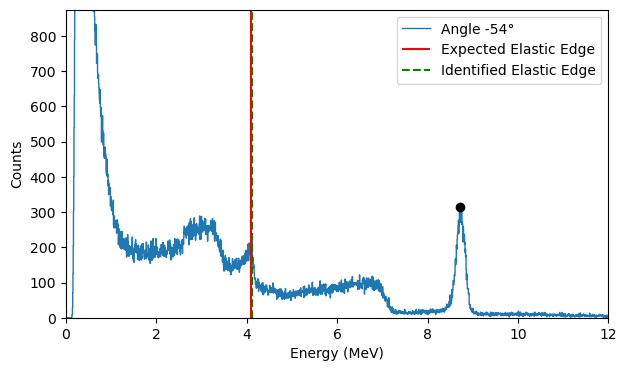

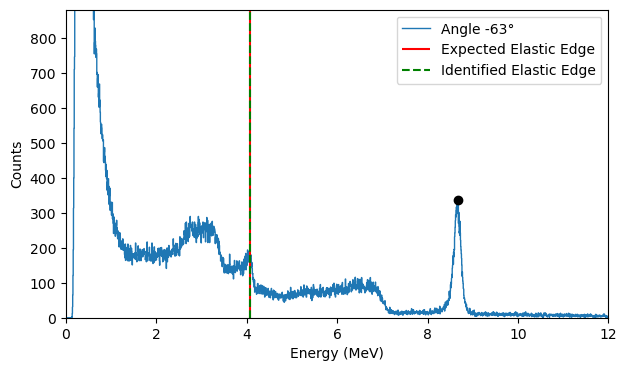

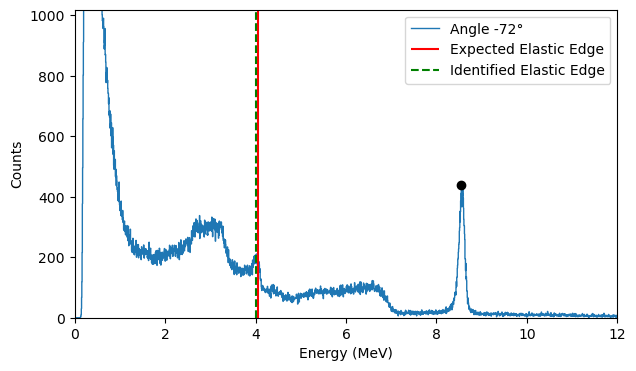

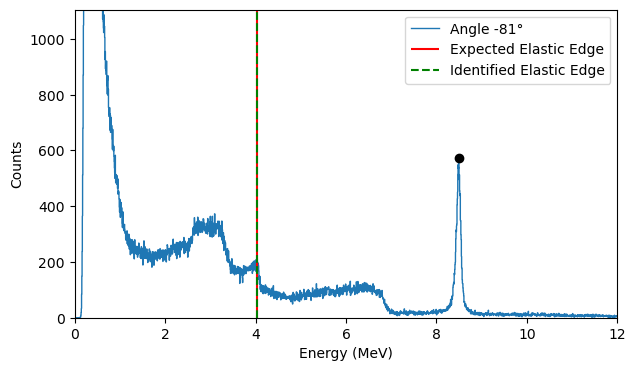

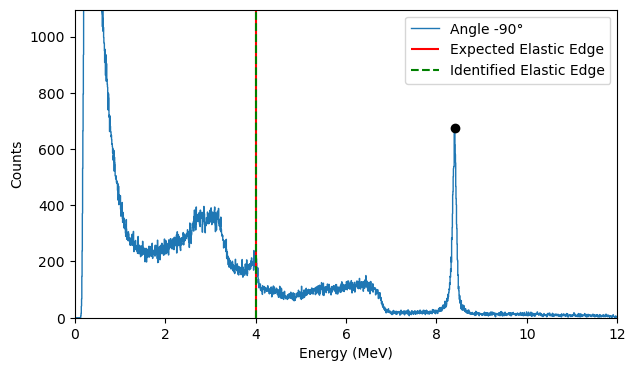

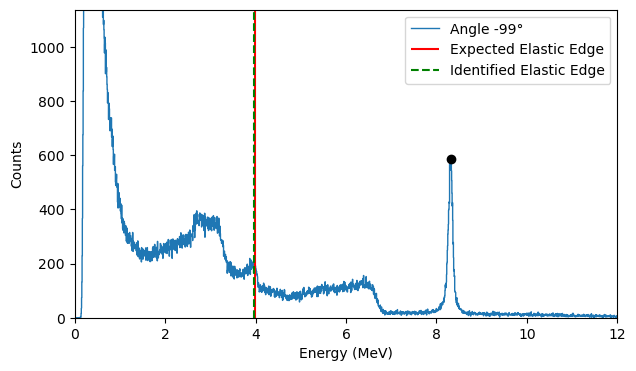

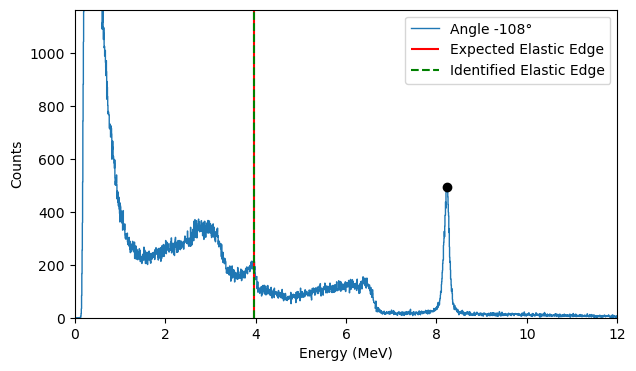

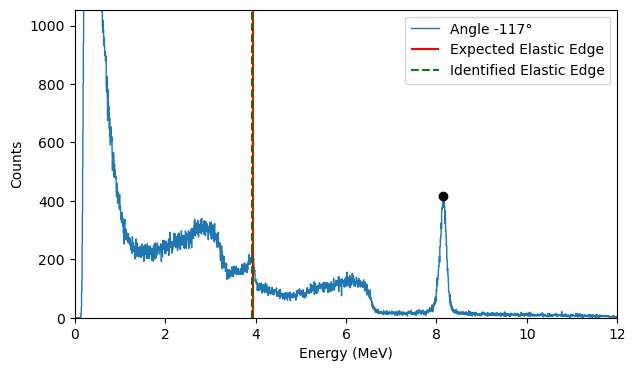

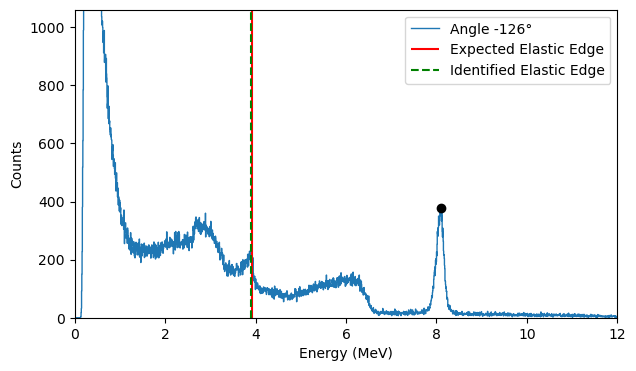

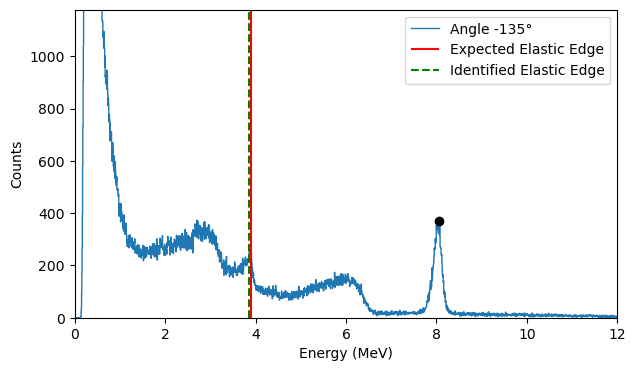

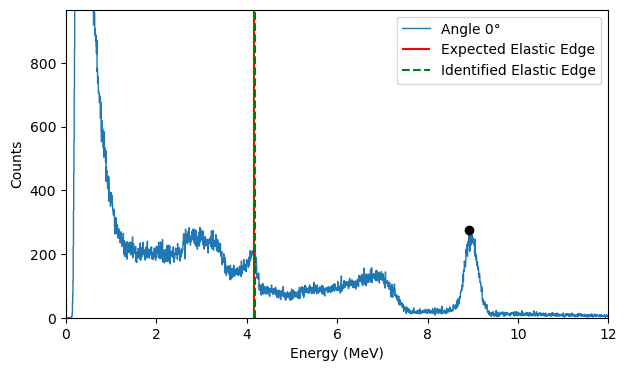

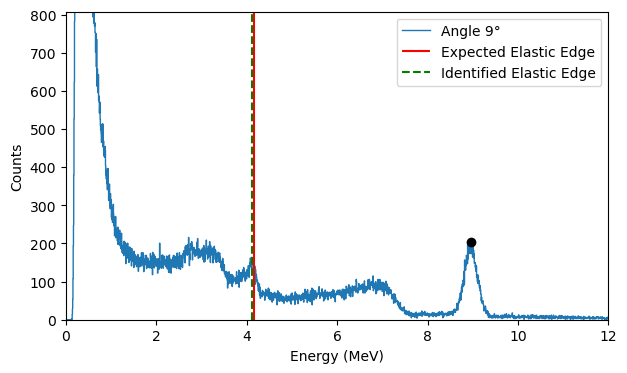

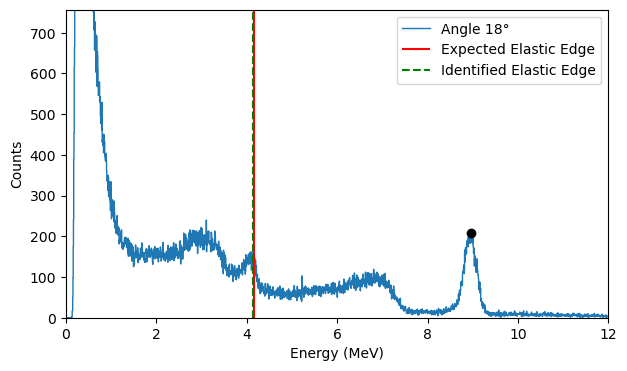

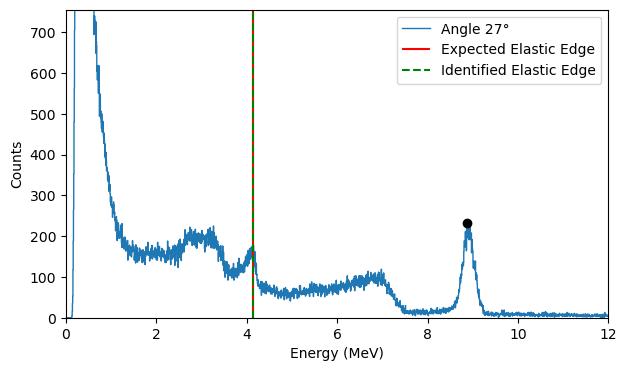

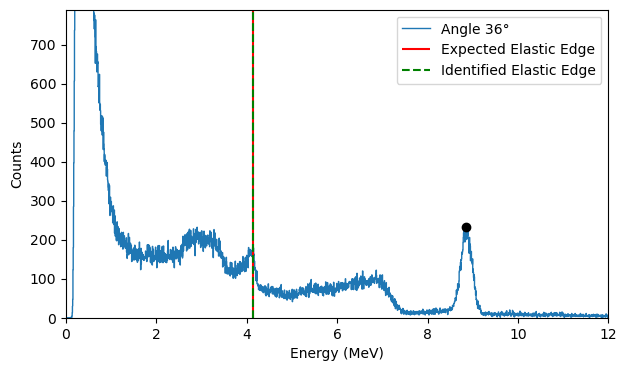

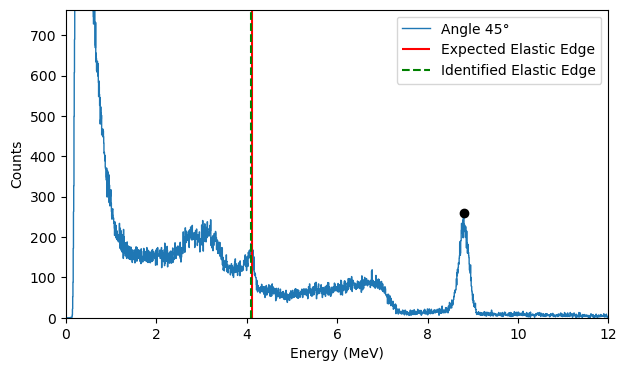

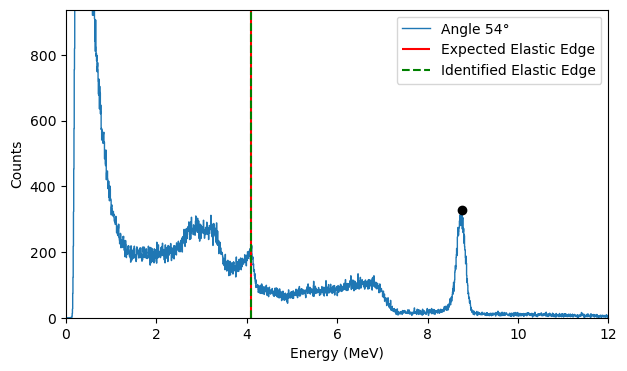

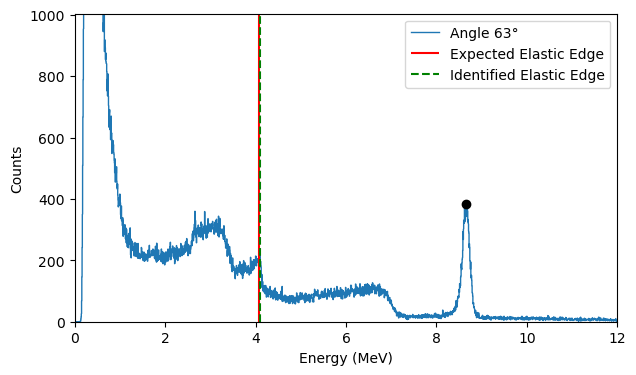

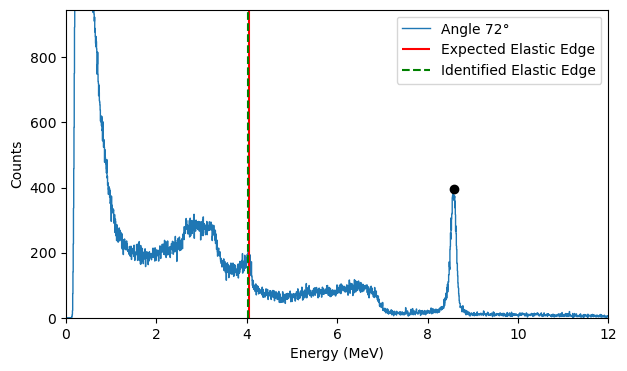

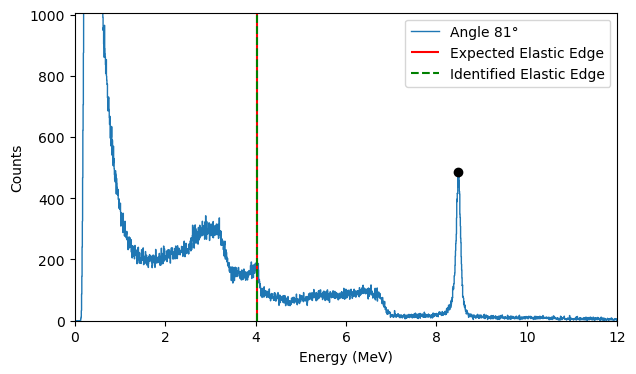

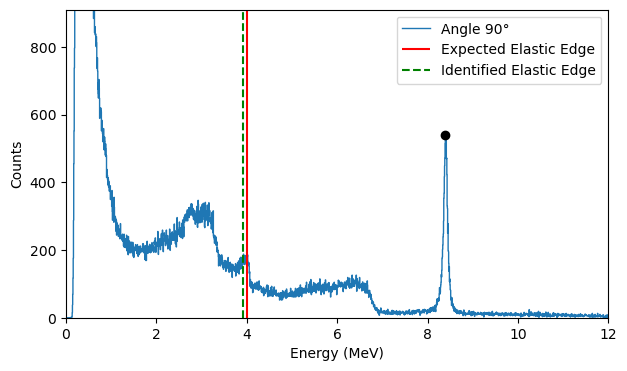

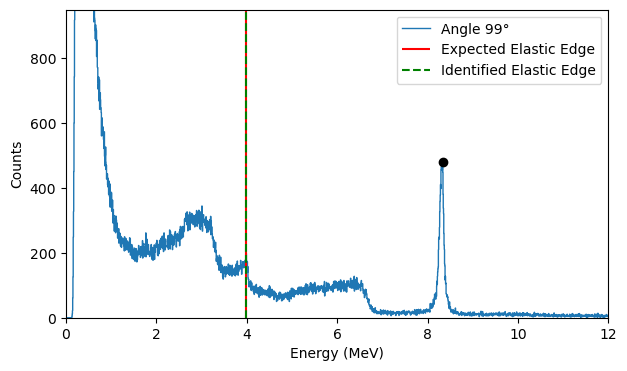

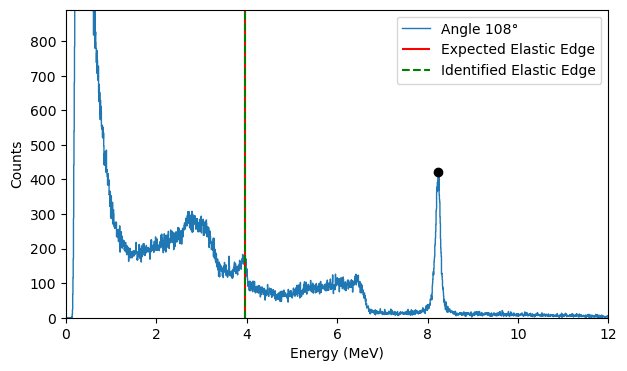

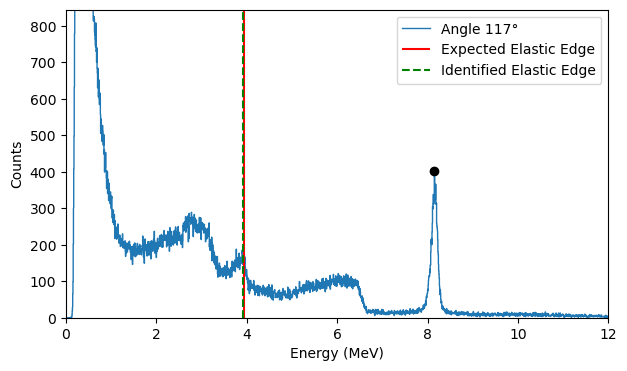

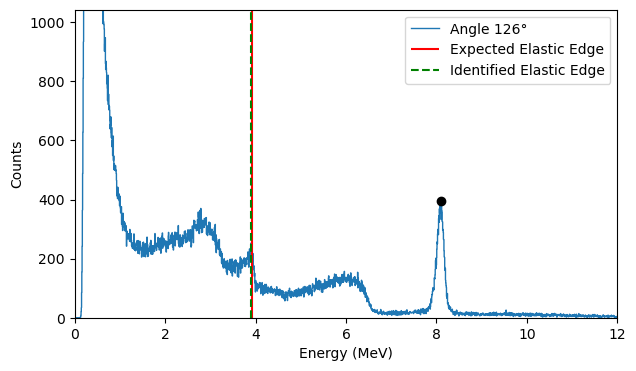

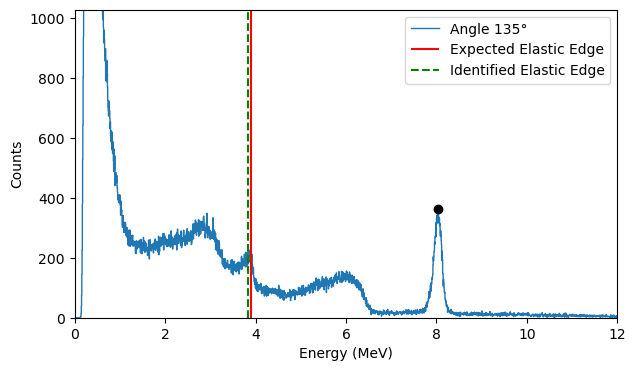

In [12]:
# Check calibration
# fig, ax = plt.subplots(figsize=[12,10], nrows=nrows, ncols=ncols)
for name in measurements:
    fig, a = plt.subplots(figsize=[7,4])
    data_processor = measurements[name]
    angle = measurements[name].angle
    a.stairs(data_processor.spectrum, data_processor.energy_bins, label=f'Angle {angle}°')
    n_alpha_peak_energy = np.mean(data_processor.energy_bins[n_alpha_inds[name]:n_alpha_inds[name]+2])
    a.plot(n_alpha_peak_energy, data_processor.spectrum[n_alpha_inds[name]], "ok")
    elastic_cliff_energy = elastic_max_energy_deposition(n_alpha_peak_energy - n_alpha_q_value)
    test_elastic_ind = np.argmin(np.abs(data_processor.energy_bins - elastic_cliff_energy))
    a.vlines(elastic_cliff_energy, 0, np.max(data_processor.spectrum), colors='r', linestyles='solid', label='Expected Elastic Edge')
    a.vlines(data_processor.energy_bins[elastic_inds[name]], 0, np.max(data_processor.spectrum), colors='g', linestyles='dashed', label='Identified Elastic Edge')
    a.set_xlim(0, 12)
    a.set_xlabel('Energy (MeV)')
    a.set_ylabel('Counts')
    a.set_ylim(0, np.max(data_processor.spectrum)*0.5)
    a.legend()

    

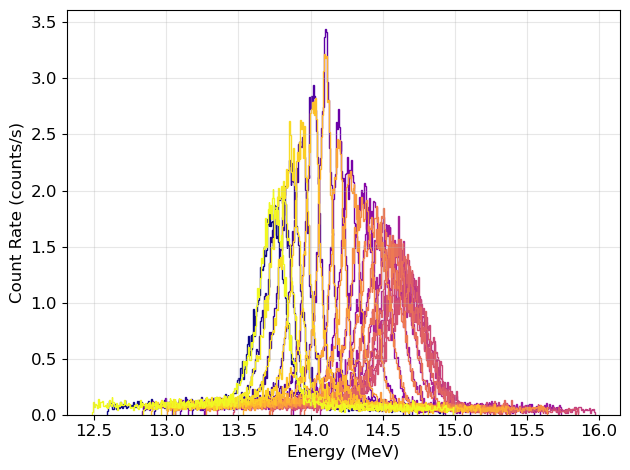

In [13]:

fig, ax = plt.subplots(nrows=1, ncols=1)
angles = np.arange(-135, 135+1, 9)
colors = plt.cm.plasma(np.linspace(0, 1, len(measurements)))
for i, angle in enumerate(angles):
    name = f'{angle}deg'
    data_processor = measurements[name]
    spectrum = data_processor.spectrum[n_alpha_bases_inds[name][0]:n_alpha_bases_inds[name][1]] / on_times[name]
    energy_bins = data_processor.energy_bins[n_alpha_bases_inds[name][0]:n_alpha_bases_inds[name][1]+1] - n_alpha_q_value
    ax.stairs(spectrum, energy_bins, label=f'Angle {angle}°', color=colors[i])
ax.set_xlabel('Energy (MeV)', fontsize=12)
ax.set_ylabel('Count Rate (counts/s)', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12)
# ax.legend(fontsize=12)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('nGen_diamond_calibrated_spectra.png', dpi=300)


In [14]:
def gaussian2(x, mu, sigma, A, B, C):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + B * x + C

def plain_gaussian(x, mu, sigma, A):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


 0deg
hist:  [0 0 0 ... 0 0 0]
guess:  [14.666864035121204, 0.5, np.float64(1.1969976496397474), 0, 0]
bounds:  ([np.float64(13.666864035121204), 0, 0, 0, 0], [np.float64(15.666864035121204), np.float64(1.0), 2.47154060302452, 1.23577030151226, 1.23577030151226])
Optimal parameters:  [1.46637086e+01 1.46108378e-01 1.16454117e+00 1.38304356e-24
 7.78125128e-02]

 0deg
hist:  [0 0 0 ... 0 0 0]
guess:  [14.666864035121204, 0.5, np.float64(1.1969976496397474), 0, 0]
bounds:  ([np.float64(13.666864035121204), 0, 0, 0, 0], [np.float64(15.666864035121204), np.float64(1.0), 2.47154060302452, 1.23577030151226, 1.23577030151226])
Optimal parameters:  [1.46637086e+01 1.46108378e-01 1.16454117e+00 1.38304356e-24
 7.78125128e-02]
hist:  [0 0 0 ... 0 0 0]
guess:  [14.666864035121204, 0.5, np.float64(1.1191851368539325)]
bounds:  ([np.float64(13.666864035121204), 0, 0], [np.float64(15.666864035121204), np.float64(1.0), 2.47154060302452])
Optimal parameters:  [14.66377934  0.14631539  1.16381283]

 -

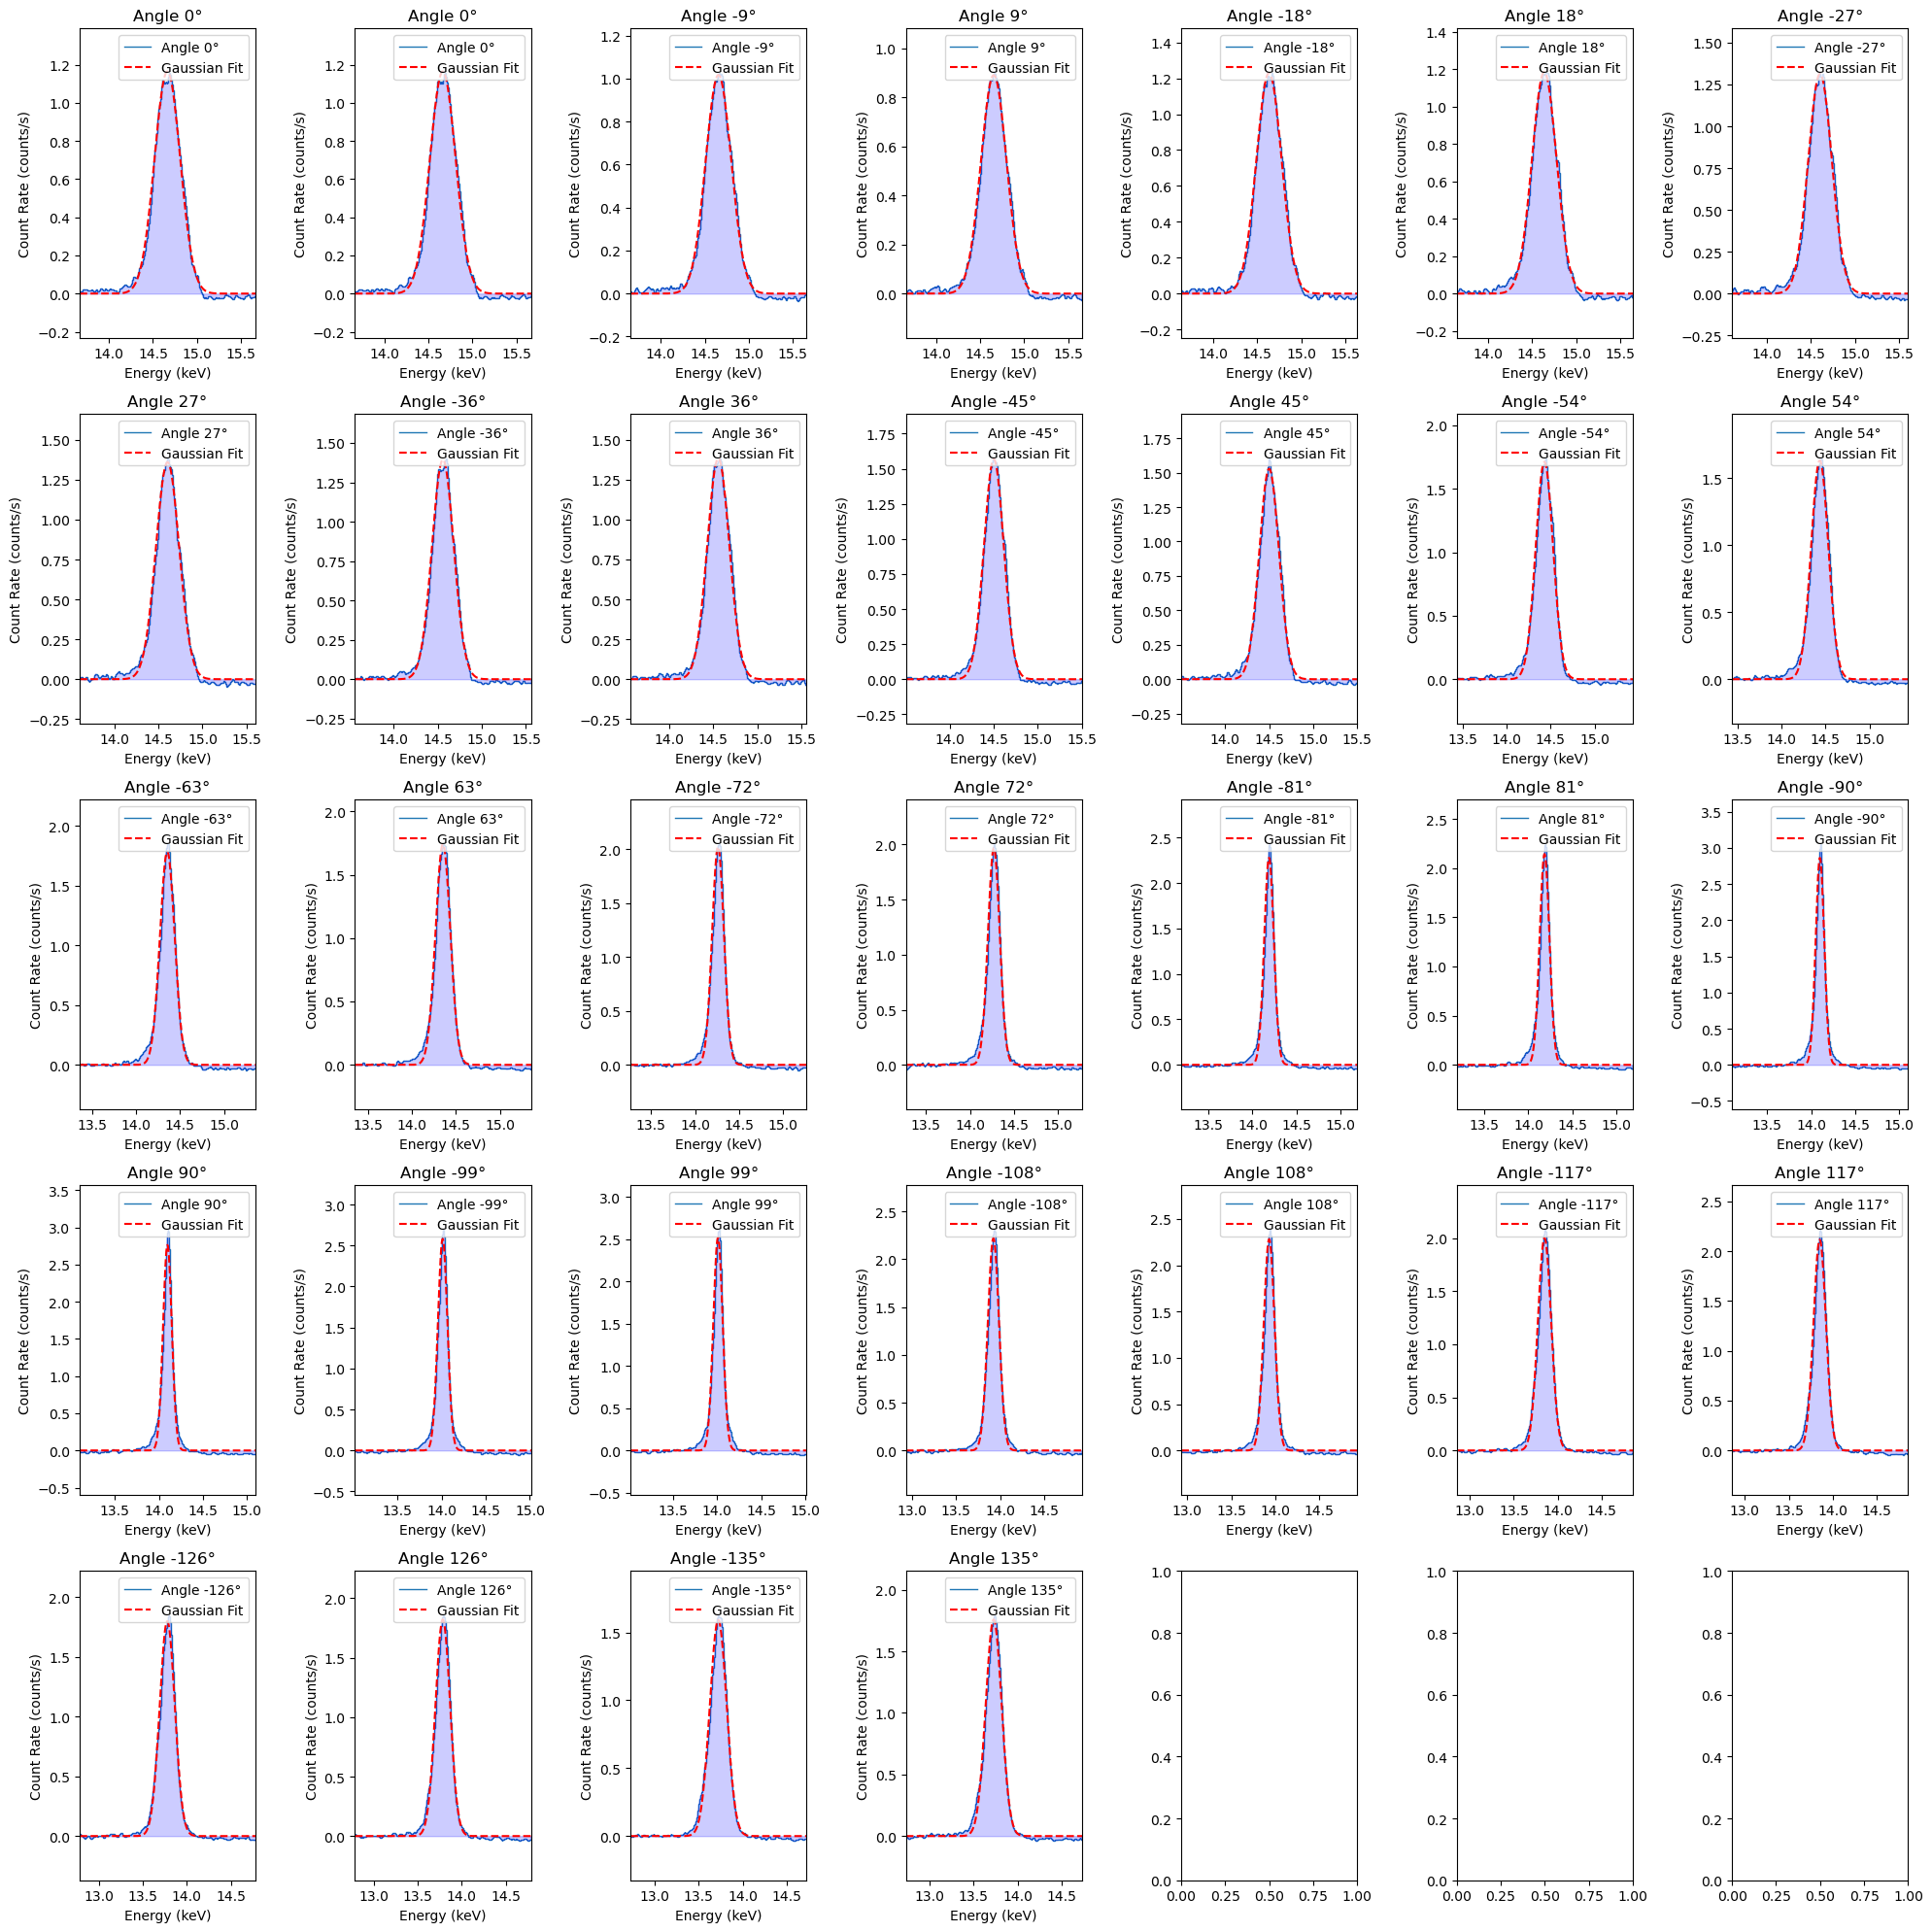

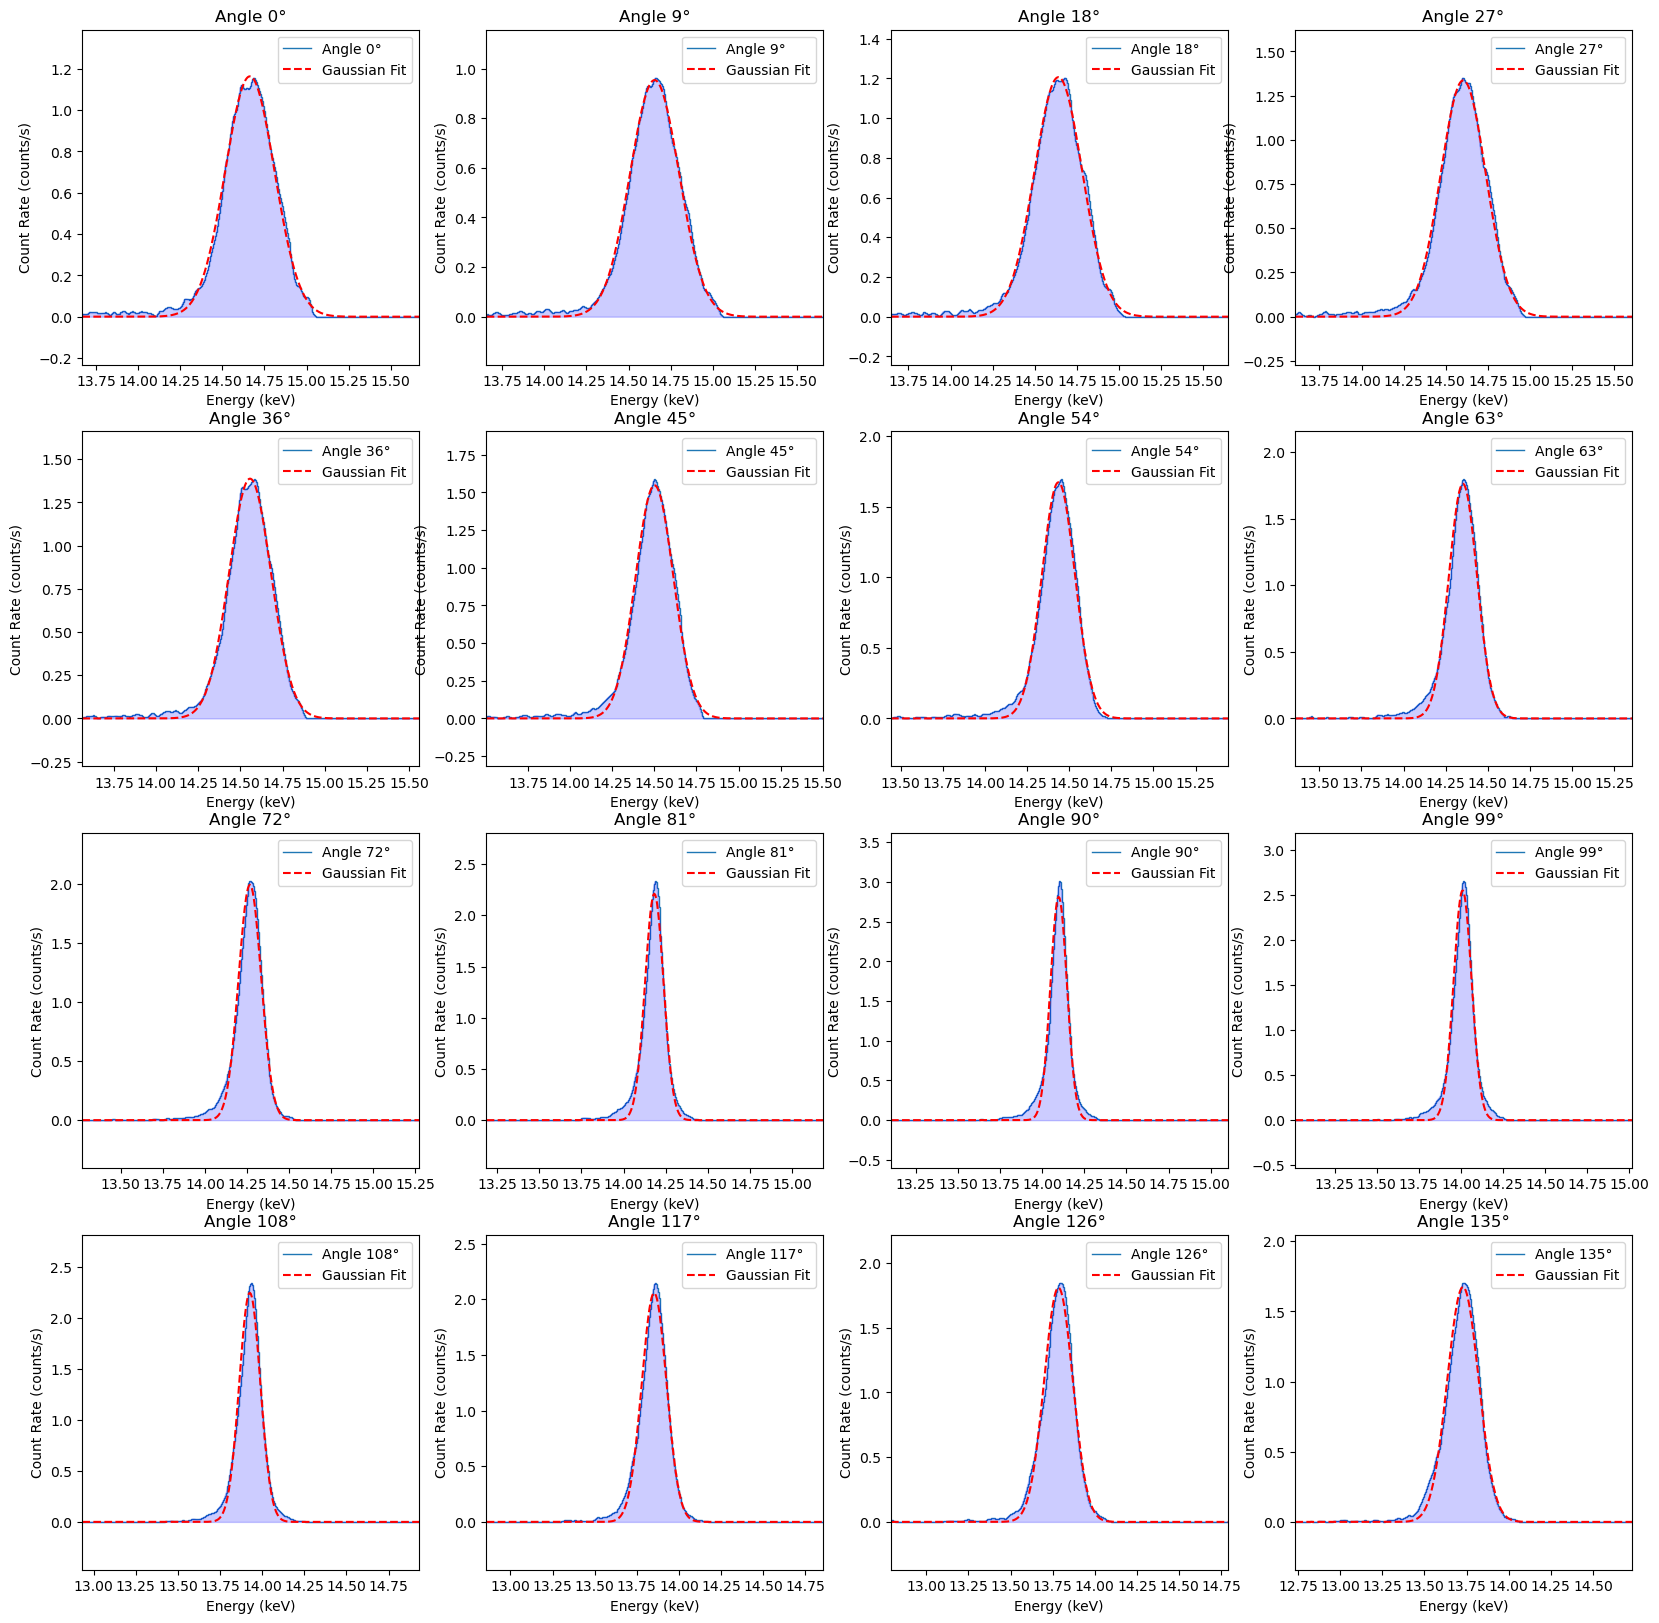

In [15]:
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d
import h5py

peak_areas = {}
averaged_areas = {}

nrows_all = int(np.sqrt(len(measurements)))
ncols_all = int(np.ceil(len(measurements) / nrows_all))
fig, ax = plt.subplots(figsize=[20,20], nrows=nrows_all, ncols=ncols_all)
ax = ax.flatten()

positive_angles = np.arange(0, 135+1, 9)
nrows = int(np.sqrt(len(positive_angles)))
ncols = int(np.ceil(len(positive_angles) / nrows))
fig2, ax2 = plt.subplots(figsize=[20, 20], nrows=nrows, ncols=ncols)
left_energy = 13.0
right_energy = 15.5

# Dictionary to store data for h5 file
h5_data = {}
for i, (a, angle) in enumerate(zip(ax2.flatten(), positive_angles)):
    spectra = {}
    for j,ang in enumerate([-angle, angle]):
        name = f'{ang}deg'
        print('\n', name)
        data_processor = measurements[name]
        angle_val = data_processor.angle
        hist, bins = np.histogram(data_processor.energy_values, bins=data_processor.channel_bins)
        bins = data_processor.energy_bins - n_alpha_q_value
        
        mean_ind = np.searchsorted(bins, n_alpha_means[name] - n_alpha_q_value)
        left_energy = bins[mean_ind] - 1.0
        right_energy = bins[mean_ind] + 1.0
        left_ind = np.searchsorted(bins, left_energy)
        right_ind = np.searchsorted(bins, right_energy)

        # normalize spectrum by count time
        spectrum = hist[left_ind:right_ind] / on_times[name]

        #smooth spectrum for fitting
        spectrum_smoothed = gaussian_filter1d(spectrum, sigma=2)

        print("hist: ", data_processor.spectrum)
        guess = [float(bins[mean_ind]), 0.5, spectrum_smoothed[int(mean_ind - left_ind)], 0, 0]
        bounds = ([left_energy, 0, 0, 0, 0],
                [right_energy, 0.5*(right_energy - left_energy), 
                 float(2*np.max(spectrum_smoothed)), 
                 float(np.max(spectrum_smoothed)), 
                 float(np.max(spectrum_smoothed))])
        print("guess: ", guess)
        print("bounds: ", bounds)
        popt, popc = curve_fit(gaussian2, 
                bins[left_ind:right_ind], 
                spectrum_smoothed, 
                p0=guess,
                bounds=bounds
                )
        
        print('Optimal parameters: ', popt)

        background_y = popt[3] * bins[left_ind:right_ind] + popt[4]

        spectrum_bg_subtracted = spectrum_smoothed - background_y

        # now take the area under the spectrum
        ax[i*2+j].stairs(spectrum_bg_subtracted, bins[left_ind:right_ind+1], label=f'Angle {angle_val}°')

        # plot gaussian fit without background
        fit_x = np.linspace(bins[left_ind], bins[right_ind], len(bins[left_ind:right_ind]))
        fit_y = gaussian2(fit_x, popt[0], popt[1], popt[2], popt[3], popt[4]) - background_y
        ax[i*2+j].plot(fit_x, fit_y, 'r--', label='Gaussian Fit')
        ax[i*2+j].fill_between(bins[left_ind:right_ind], spectrum_bg_subtracted, alpha=0.2, color='b')

        ax[i*2+j].set_xlabel('Energy (keV)')
        ax[i*2+j].set_ylabel('Count Rate (counts/s)')
        ax[i*2+j].set_title(f'Angle {measurements[name].angle}°')
        ax[i*2+j].legend()
        ax[i*2+j].set_xlim(left_energy, right_energy)
        ax[i*2+j].set_ylim(np.max(spectrum_bg_subtracted)*(-0.2), np.max(spectrum_bg_subtracted)*1.2)

        # now take the area under the spectrum
        peak_areas[name] = np.trapezoid(spectrum_bg_subtracted, bins[left_ind:right_ind])
        peak_areas[name] = np.sum(spectrum_bg_subtracted)
        spectra[name] = spectrum_bg_subtracted
    if angle == 0:
        averaged_spectrum = spectra[f'{angle}deg']
    else:
        averaged_spectrum = (spectra[f'{angle}deg'] + spectra[f'-{angle}deg']) / 2

    # now to ensure all parts of the spectrum are positive for plotting
    averaged_spectrum[averaged_spectrum < 0] = 0

    averaged_areas[angle] = np.trapezoid(averaged_spectrum, bins[left_ind:right_ind])

    print("hist: ", data_processor.spectrum)
    guess = [float(bins[mean_ind]), 0.5, averaged_spectrum[int(mean_ind - left_ind)]]
    bounds = ([left_energy, 0, 0],
              [right_energy, 
               0.5*(right_energy - left_energy), 
               float(2*np.max(spectrum_smoothed))])
    print("guess: ", guess)
    print("bounds: ", bounds)
    popt, popc = curve_fit(plain_gaussian, 
              bins[left_ind:right_ind], 
              averaged_spectrum, 
              p0=guess,
              bounds=bounds
             )
    
    print('Optimal parameters: ', popt)


    # now to ensure all parts of the spectrum are positive for plotting
    # spectrum_bg_subtracted[spectrum_bg_subtracted < 0] = 0

    # now take the area under the spectrum
    a.stairs(averaged_spectrum, bins[left_ind:right_ind+1], label=f'Angle {angle_val}°')

    # plot gaussian fit without background
    fit_x = np.linspace(bins[left_ind], bins[right_ind], len(bins[left_ind:right_ind]))
    fit_y = plain_gaussian(fit_x, *popt)
    a.plot(fit_x, fit_y, 'r--', label='Gaussian Fit')
    a.fill_between(bins[left_ind:right_ind], averaged_spectrum, alpha=0.2, color='b')

    a.set_xlabel('Energy (keV)')
    a.set_ylabel('Count Rate (counts/s)')
    a.set_title(f'Angle {measurements[name].angle}°')
    a.legend()
    a.set_xlim(left_energy, right_energy)
    a.set_ylim(np.max(averaged_spectrum)*(-0.2), np.max(averaged_spectrum)*1.2)

    # Store data for h5 file
    h5_data[name] = {
        'angle': angle_val,
        'energy_bins': bins[left_ind:right_ind] * 1e6,  # convert to eV
        'spectrum': averaged_spectrum,
    }

fig.tight_layout()

# Save data to h5 file
h5_filename = '../../data/diamond_processed_spectra.h5'
with h5py.File(h5_filename, 'w') as f:
    # Add metadata
    f.attrs['description'] = 'Diamond detector processed spectra by angle'
    
    for name, data in h5_data.items():
        grp = f.create_group(name)
        grp.attrs['angle'] = data['angle']
        grp.create_dataset('energy_bins', data=data['energy_bins'][::])
        grp.create_dataset('spectrum', data=data['spectrum'])

print(f'\nSaved processed spectra to {h5_filename}')

In [16]:
# get diamond spectrum from openmc
import openmc
with openmc.StatePoint('../statepoint.100.h5') as sp:
    spectrum_tally = sp.get_tally(name='spectrum tally')

tally_n_alpha_rates = spectrum_tally.get_reshaped_data(value='mean').squeeze()[:,:,1]
simulation_n_alpha_spectra = {}
print('tally_n_alpha_rates shape: ', tally_n_alpha_rates.shape)
cells = openmc.Model.from_model_xml('../model.xml').geometry.get_all_material_cells()
tally_cell_ids = spectrum_tally.find_filter(openmc.CellFilter).bins
sim_energy_bins = spectrum_tally.find_filter(openmc.EnergyFilter).bins
sim_energy_bins = np.append(sim_energy_bins[:,0], sim_energy_bins[-1,1])
print('Sim energy bins: ', sim_energy_bins)

for i,tally_cell_id in enumerate(tally_cell_ids):
    cell = cells[tally_cell_id]
    cell_angle = int(cell.name[len("Diamond_detector_"):-len("deg")])

    print(f'Tally cell ID: {tally_cell_id}, Cell angle: {cell_angle}')
    simulation_n_alpha_spectra[cell_angle] = tally_n_alpha_rates[i, :]

tally_n_alpha_rates shape:  (31, 517)
Sim energy bins:  [12600000. 12605600. 12611200. 12616800. 12622400. 12628000. 12633600.
 12639200. 12644800. 12650400. 12656000. 12661600. 12667200. 12672800.
 12678400. 12684000. 12689600. 12695200. 12700800. 12706400. 12712000.
 12717600. 12723200. 12728800. 12734400. 12740000. 12745600. 12751200.
 12756800. 12762400. 12768000. 12773600. 12779200. 12784800. 12790400.
 12796000. 12801600. 12807200. 12812800. 12818400. 12824000. 12829600.
 12835200. 12840800. 12846400. 12852000. 12857600. 12863200. 12868800.
 12874400. 12880000. 12885600. 12891200. 12896800. 12902400. 12908000.
 12913600. 12919200. 12924800. 12930400. 12936000. 12941600. 12947200.
 12952800. 12958400. 12964000. 12969600. 12975200. 12980800. 12986400.
 12992000. 12997600. 13003200. 13008800. 13014400. 13020000. 13025600.
 13031200. 13036800. 13042400. 13048000. 13053600. 13059200. 13064800.
 13070400. 13076000. 13081600. 13087200. 13092800. 13098400. 13104000.
 13109600. 13115200. 

/home/cdunn314/miniconda3/envs/ngen/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=1.
  warn(msg, IDWarning)
/home/cdunn314/miniconda3/envs/ngen/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=2.
  warn(msg, IDWarning)
/home/cdunn314/miniconda3/envs/ngen/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)
/home/cdunn314/miniconda3/envs/ngen/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=4.
  warn(msg, IDWarning)
/home/cdunn314/miniconda3/envs/ngen/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=5.
  warn(msg, IDWarning)
/home/cdunn314/miniconda3/envs/ngen/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=

energy_bins start:  12.59214166657759  energy_bins end:  14.916284210574535
average energy bins:  0.005668640351212062  average sim energy bins:  0.005600000000000002
energy_bins start:  12.915254166596677  energy_bins end:  14.683869956174842
average energy bins:  0.005668640351212068  average sim energy bins:  0.005600000000000002
energy_bins start:  13.056970175376978  energy_bins end:  14.644189473716356
average energy bins:  0.005668640351212062  average sim energy bins:  0.005600000000000002
energy_bins start:  13.176011622752432  energy_bins end:  14.70654451757969
average energy bins:  0.005668640351212069  average sim energy bins:  0.005600000000000002
energy_bins start:  13.039964254323342  energy_bins end:  14.989976535140293
average energy bins:  0.005668640351212067  average sim energy bins:  0.005600000000000002
energy_bins start:  13.096650657835463  energy_bins end:  15.103349342164535
average energy bins:  0.005668640351212067  average sim energy bins:  0.0056000000000

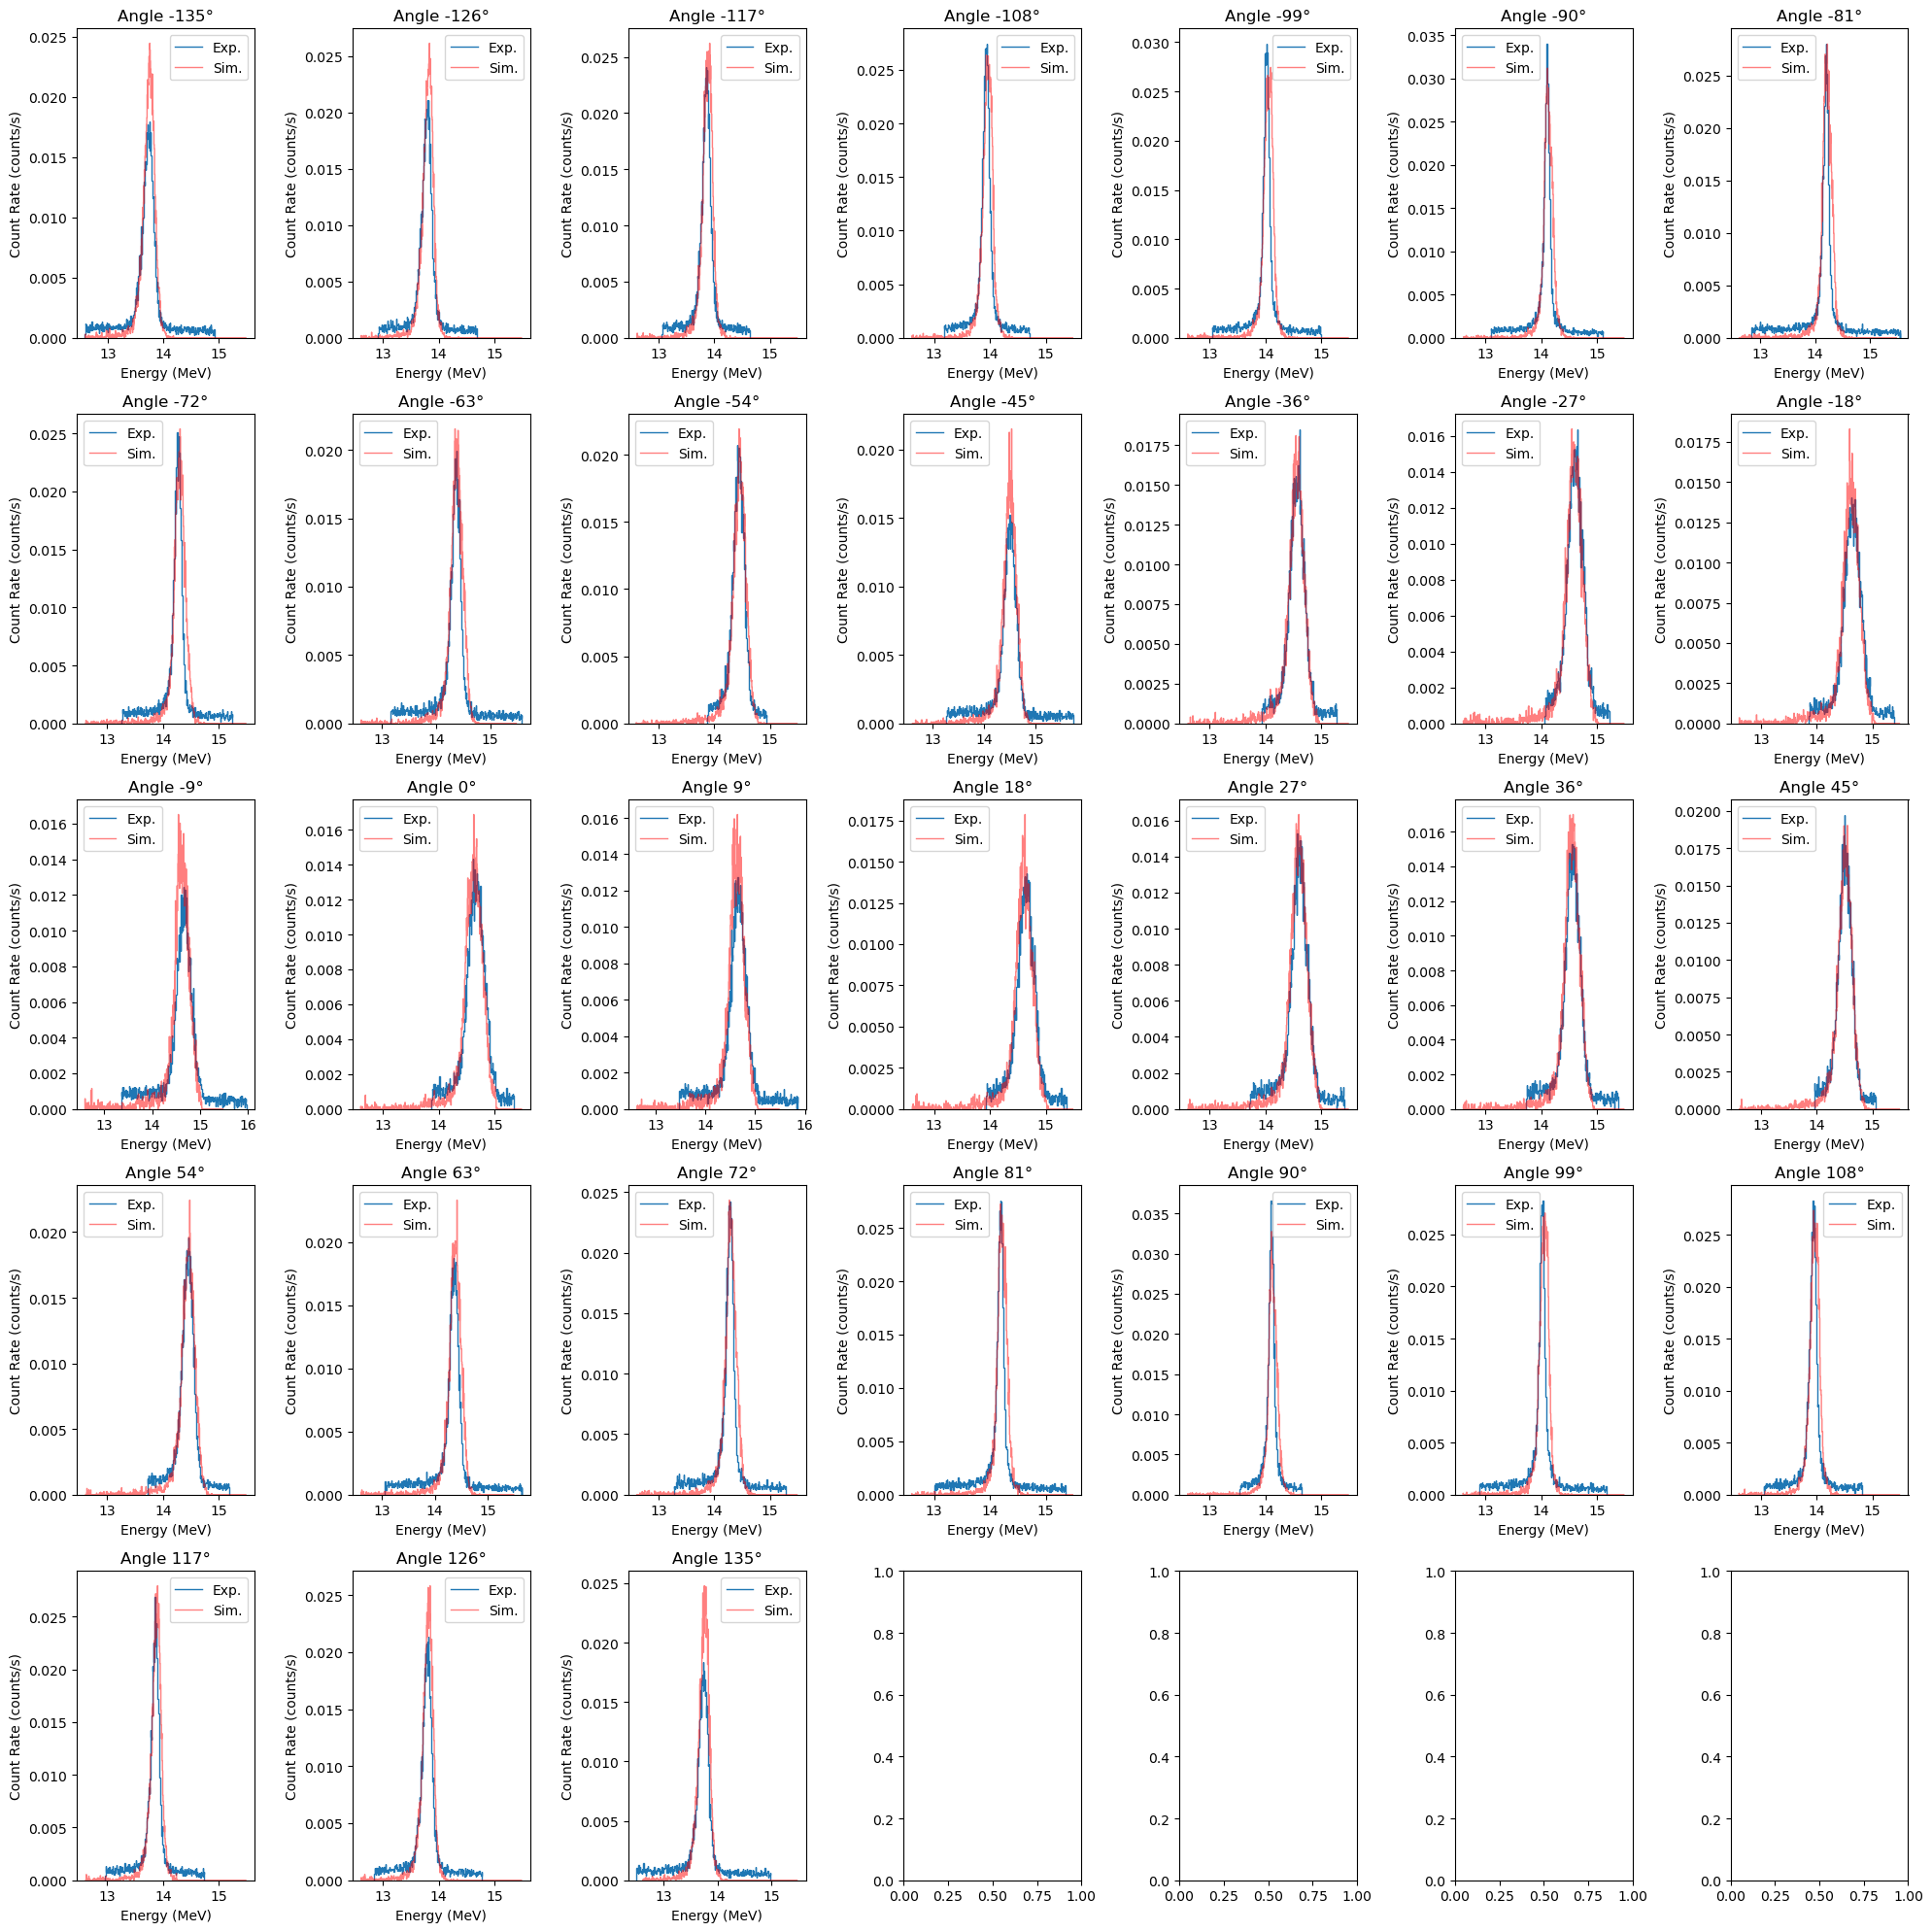

In [17]:
nrows_all = int(np.sqrt(len(measurements)))
ncols_all = int(np.ceil(len(measurements) / nrows_all))
fig, ax = plt.subplots(figsize=[20,20], nrows=nrows_all, ncols=ncols_all)
ax = ax.flatten()

for i, (a, angle) in enumerate(zip(ax.flatten(), angles)):
    name = f'{angle}deg'
    data_processor = measurements[name]
    spectrum = data_processor.spectrum[n_alpha_bases_inds[name][0]:n_alpha_bases_inds[name][1]] / on_times[name]
    energy_bins = data_processor.energy_bins[n_alpha_bases_inds[name][0]:n_alpha_bases_inds[name][1]+1] - n_alpha_q_value
    print("energy_bins start: ", energy_bins[0], " energy_bins end: ", energy_bins[-1])
    print("average energy bins: ", np.mean(np.diff(energy_bins)), " average sim energy bins: ", np.mean(np.diff(sim_energy_bins/1e6)))
    a.stairs(spectrum / np.sum(spectrum), energy_bins, label=f'Exp.')

    # plot simulation spectrum
    a.stairs(simulation_n_alpha_spectra[angle] / np.sum(simulation_n_alpha_spectra[angle]), sim_energy_bins/1e6, label='Sim.', color='r', alpha=0.5)
    
    a.set_xlabel('Energy (MeV)')
    a.set_ylabel('Count Rate (counts/s)')
    a.set_yscale('linear')
    a.set_title(f'Angle {angle}°')
    a.legend()
fig.tight_layout()

Description: Diamond detector processed spectra by angle

Available angles:
  0deg: angle=0°, bins shape=(353,), spectrum shape=(353,)
  108deg: angle=108°, bins shape=(353,), spectrum shape=(353,)
  117deg: angle=117°, bins shape=(353,), spectrum shape=(353,)
  126deg: angle=126°, bins shape=(353,), spectrum shape=(353,)
  135deg: angle=135°, bins shape=(353,), spectrum shape=(353,)
  18deg: angle=18°, bins shape=(353,), spectrum shape=(353,)
  27deg: angle=27°, bins shape=(353,), spectrum shape=(353,)
  36deg: angle=36°, bins shape=(353,), spectrum shape=(353,)
  45deg: angle=45°, bins shape=(353,), spectrum shape=(353,)
  54deg: angle=54°, bins shape=(353,), spectrum shape=(353,)
  63deg: angle=63°, bins shape=(353,), spectrum shape=(353,)
  72deg: angle=72°, bins shape=(353,), spectrum shape=(353,)
  81deg: angle=81°, bins shape=(353,), spectrum shape=(353,)
  90deg: angle=90°, bins shape=(353,), spectrum shape=(353,)
  99deg: angle=99°, bins shape=(353,), spectrum shape=(353,)
  9

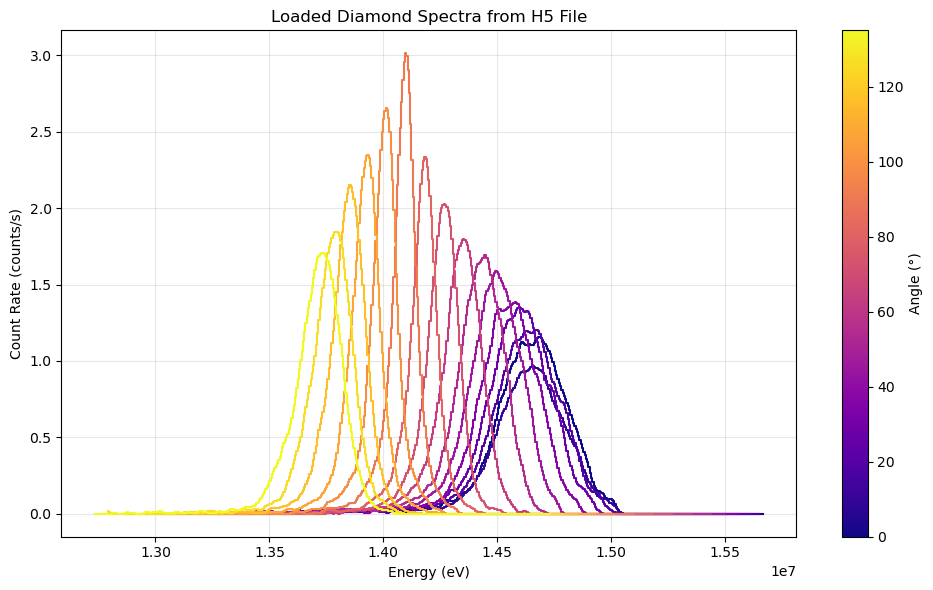

In [18]:
# Read the processed spectra from h5 file
import h5py
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

h5_filename = '../../data/diamond_processed_spectra.h5'
with h5py.File(h5_filename, 'r') as f:
    print(f'Description: {f.attrs["description"]}')
    print(f'\nAvailable angles:')
    
    loaded_data = {}
    for name in f.keys():
        grp = f[name]
        loaded_data[name] = {
            'angle': grp.attrs['angle'],
            'energy_bins': grp['energy_bins'][:],
            'spectrum': grp['spectrum'][:]
        }
        print(f'  {name}: angle={loaded_data[name]["angle"]}°, '
              f'bins shape={loaded_data[name]["energy_bins"].shape}, '
              f'spectrum shape={loaded_data[name]["spectrum"].shape}')

# Plot loaded data to verify
fig, ax = plt.subplots(figsize=[10, 6])

# Get angle range for color normalization
angles = [data['angle'] for data in loaded_data.values()]
norm = Normalize(vmin=min(angles), vmax=max(angles))
cmap = plt.cm.plasma
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

for name, data in sorted(loaded_data.items(), key=lambda x: x[1]['angle']):
    color = cmap(norm(data['angle']))
    ax.step(data['energy_bins'], data['spectrum'], label=f'{data["angle"]}°', color=color)

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Count Rate (counts/s)')
ax.set_title('Loaded Diamond Spectra from H5 File')
ax.grid(alpha=0.3)

# Add colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Angle (°)')

fig.tight_layout()

Angle: -135  n,alpha rate (counts/s):  67.45609558226933  on time:  202.0
Angle: -126  n,alpha rate (counts/s):  68.51536398636836  on time:  187.0
Angle: -117  n,alpha rate (counts/s):  66.94064853457911  on time:  184.0
Angle: -108  n,alpha rate (counts/s):  62.34426217161156  on time:  199.0
Angle: -99  n,alpha rate (counts/s):  61.50490179294367  on time:  200.0
Angle: -90  n,alpha rate (counts/s):  61.63718858448484  on time:  196.0
Angle: -81  n,alpha rate (counts/s):  55.31814300570674  on time:  210.0
Angle: -72  n,alpha rate (counts/s):  59.88017196388155  on time:  191.0
Angle: -63  n,alpha rate (counts/s):  65.81824976625961  on time:  163.0
Angle: -54  n,alpha rate (counts/s):  75.10226647344444  on time:  162.0
Angle: -45  n,alpha rate (counts/s):  78.05314304099844  on time:  164.0
Angle: -36  n,alpha rate (counts/s):  76.14370418570786  on time:  155.0
Angle: -27  n,alpha rate (counts/s):  78.1261270451508  on time:  159.0
Angle: -18  n,alpha rate (counts/s):  77.9930896

Text(0, 0.5, '(n,α) Detection Rate (counts/s)')

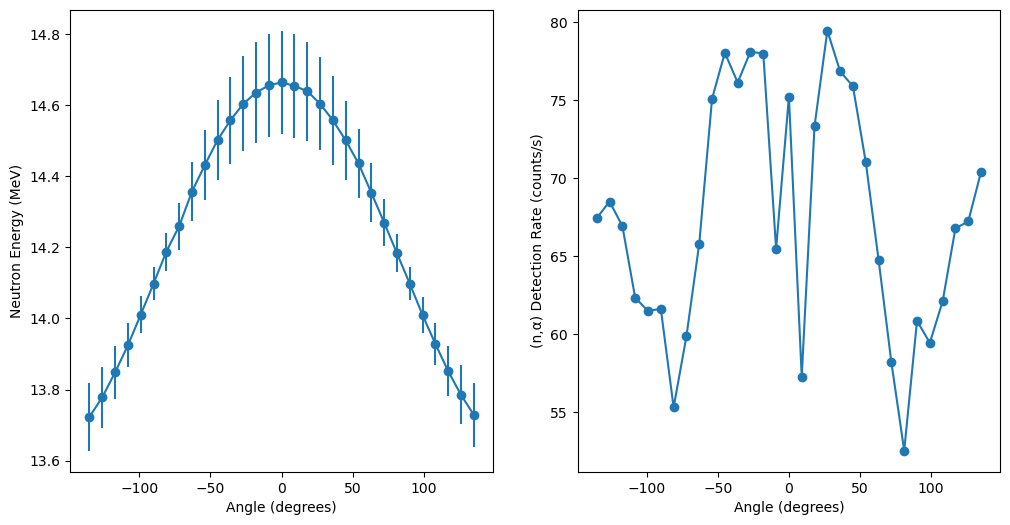

In [19]:
# plot neutron energy vs angle and neutron rate vs angle
fig, ax = plt.subplots(ncols=2, figsize=[12,6])
neutron_energies = []
neutron_energy_errs = []
n_alpha_rates = []
n_alpha_rate_errs = []
angles = np.arange(-135, 135+1, 9)
for angle in angles:
    name = f'{angle}deg'
    data_processor = measurements[name]
    # n_alpha_peak_energy = np.mean(data_processor.energy_bins[n_alpha_inds[name]:n_alpha_inds[name]+2])
    n_alpha_peak_energy = n_alpha_means[name]
    n_alpha_energy_err = n_alpha_stds[name]
    neutron_energies.append(n_alpha_peak_energy - n_alpha_q_value)
    neutron_energy_errs.append(n_alpha_energy_err)
    peak_hist = data_processor.spectrum[n_alpha_bases_inds[name][0]:n_alpha_bases_inds[name][1]]

    print('Angle:', angle, ' n,alpha rate (counts/s): ', peak_areas[name], ' on time: ', on_times[name])
    n_alpha_rate = peak_areas[name] 
    n_alpha_rates.append(n_alpha_rate)
    # n_alpha_rate_err = np.sqrt(peak_areas[name])
    n_alpha_rate_err = 0.0
    n_alpha_rate_errs.append(n_alpha_rate_err)

ax[0].errorbar(angles, neutron_energies, yerr=neutron_energy_errs, fmt="o-")
ax[0].set_xlabel('Angle (degrees)')
ax[0].set_ylabel('Neutron Energy (MeV)')
ax[1].errorbar(angles, n_alpha_rates, yerr=n_alpha_rate_errs, fmt="o-")
ax[1].set_xlabel('Angle (degrees)')
ax[1].set_ylabel('(n,α) Detection Rate (counts/s)')


In [20]:
import json
processed_data_file = "../../data/processed_data.json"

processed_data = {
    "diamond": {}
}
for angle, neutron_energy, neutron_energy_err, n_alpha_rate, n_alpha_rate_err in zip(angles, neutron_energies, neutron_energy_errs, n_alpha_rates, n_alpha_rate_errs):
    processed_data["diamond"][int(angle)] = {
        "neutron_energy": {
            "value": float(neutron_energy),
            "error": float(neutron_energy_err),
            "unit": "MeV"
        },
        "n_alpha_rate": {
            "value": float(n_alpha_rate),
            "error": float(n_alpha_rate_err),
            "unit": "counts / second"
        }
    }
processed_data["diamond"]["angles"] = [int(a) for a in angles]
processed_data["diamond"]["neutron_energies"] = {"values": [float(x) for x in neutron_energies], 
                                                 "errors": [float(x) for x in neutron_energy_errs],
                                                 "unit": "MeV"}
processed_data["diamond"]["n_alpha_rates"] = {"values": [float(x) for x in n_alpha_rates], 
                                              "errors": [float(x) for x in n_alpha_rate_errs], 
                                              "unit": "counts / second"}

try:
    with open(processed_data_file, "r") as f:
        existing_data = json.load(f)
except FileNotFoundError:
    print(f"Processed data file not found, creating it in {processed_data_file}")
    existing_data = {}

existing_data.update(processed_data)
print(f"Updated processed data: {existing_data}")

with open(processed_data_file, "w") as f:
    json.dump(existing_data, f, indent=4)

print(f"Processed data stored in {processed_data_file}")

Updated processed data: {'foils': {'NaI': {'Al27': {'-90': {'gamma_emitted': {'Al27(n,alpha)Na24': [[11576025.080618223], [10441082.126235044]]}, 'gamma_emitted_err': {'Al27(n,alpha)Na24': [[34345.11906003131], [26253.65972512131]]}, 'factors': {'Al27(n,alpha)Na24': [[4.501834405925422e+26], [4.503620634348447e+26]]}, 'rate': 300391.9160403431, 'rate_err': 589.8375647999444, 'units': 'n/s', 'number_of_measurements': 2}}, 'Zr90': {'90': {'gamma_emitted': {'Zr90(n,2n)Zr89': [[392191.6980013817], [371574.4072193478]]}, 'gamma_emitted_err': {'Zr90(n,2n)Zr89': [[5492.326108677161], [4347.112663941894]]}, 'factors': {'Zr90(n,2n)Zr89': [[1.1675299845734742e+24], [1.1672838857217892e+24]]}, 'rate': 906416.0763120377, 'rate_err': 8312.566756459739, 'units': 'n/s', 'number_of_measurements': 2}, '-90': {'gamma_emitted': {'Zr90(n,2n)Zr89': [[263066.2291824464], [250688.2279555521]]}, 'gamma_emitted_err': {'Zr90(n,2n)Zr89': [[4489.766725919174], [3564.2379972038416]]}, 'factors': {'Zr90(n,2n)Zr89':

Angle: 0  integral:  75.23865064829886  on time:  201.0  rate:  95.90547263681592
Angle: 9  integral:  57.29805743378704  on time:  196.0  rate:  81.3188775510204
Angle: 18  integral:  73.34669328512364  on time:  156.0  rate:  93.71474358974359
Angle: 27  integral:  79.46382907538592  on time:  145.0  rate:  105.00689655172414
Angle: 36  integral:  76.86109720145555  on time:  150.0  rate:  101.00666666666666
Angle: 45  integral:  75.89282454151316  on time:  141.0  rate:  93.23758865248227
Angle: 54  integral:  71.03678588040366  on time:  177.0  rate:  94.84463276836158
Angle: 63  integral:  64.77973460378612  on time:  198.0  rate:  103.6969696969697
Angle: 72  integral:  58.200805850530244  on time:  182.0  rate:  89.6923076923077
Angle: 81  integral:  52.5416266450506  on time:  197.0  rate:  89.15736040609137
Angle: 90  integral:  60.86593584692838  on time:  168.0  rate:  87.61607142857143
Angle: 99  integral:  59.45865085470491  on time:  170.0  rate:  99.9235294117647
Angle: 

Text(0, 0.5, '(n,α) Detection Rate (counts/s)')

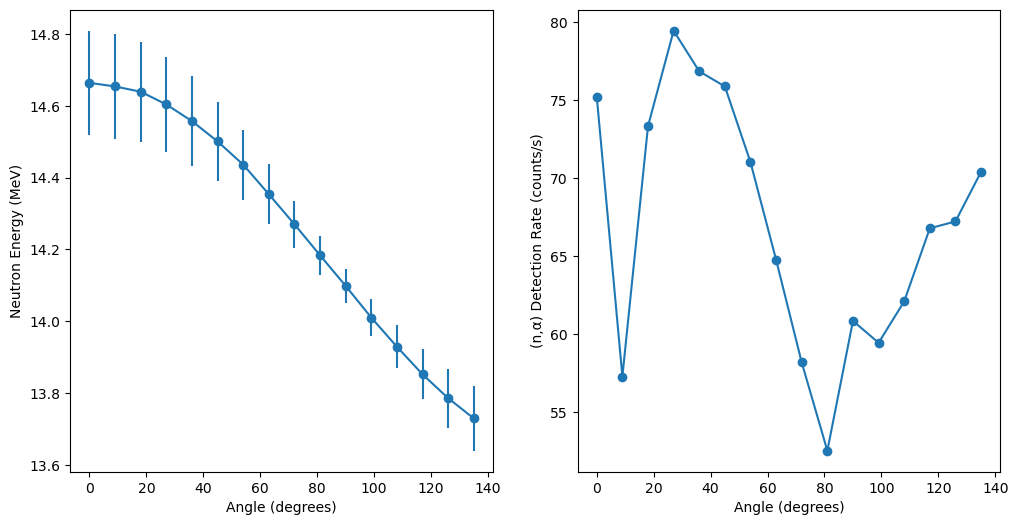

In [21]:
# plot neutron energy vs angle and neutron rate vs angle 
# for averaged spectrum (averaging positive and negative angles)
fig, ax = plt.subplots(ncols=2, figsize=[12,6])
neutron_energies = []
neutron_energy_errs = []
n_alpha_rates = []
n_alpha_rate_errs = []

for angle in positive_angles:
    name = f'{angle}deg'
    data_processor = measurements[name]
    # n_alpha_peak_energy = np.mean(data_processor.energy_bins[n_alpha_inds[name]:n_alpha_inds[name]+2])
    n_alpha_peak_energy = n_alpha_means[name]
    n_alpha_energy_err = n_alpha_stds[name]
    neutron_energies.append(n_alpha_peak_energy - n_alpha_q_value)
    neutron_energy_errs.append(n_alpha_energy_err)
    peak_hist = data_processor.spectrum[n_alpha_bases_inds[name][0]:n_alpha_bases_inds[name][1]]

    print('Angle:', angle, ' integral: ', peak_areas[name], ' on time: ', on_times[name], ' rate: ', np.trapezoid(peak_hist) / on_times[name])
    n_alpha_rate = peak_areas[name] 
    n_alpha_rates.append(n_alpha_rate)
    # n_alpha_rate_err = np.sqrt(peak_areas[name])
    n_alpha_rate_err = 0.0
    n_alpha_rate_errs.append(n_alpha_rate_err)

ax[0].errorbar(positive_angles, neutron_energies, yerr=neutron_energy_errs, fmt="o-")
ax[0].set_xlabel('Angle (degrees)')
ax[0].set_ylabel('Neutron Energy (MeV)')
ax[1].errorbar(positive_angles, n_alpha_rates, yerr=n_alpha_rate_errs, fmt="o-")
ax[1].set_xlabel('Angle (degrees)')
ax[1].set_ylabel('(n,α) Detection Rate (counts/s)')
